# Waste Classification – Integrated Group Preprocessing Pipeline

## IT2011 – Artificial Intelligence and Machine Learning

### Group Preprocessing Pipeline

This notebook integrates the preprocessing techniques completed independently
by all six group members into one reproducible preprocessing pipeline.

The individual member notebooks are preserved unchanged and serve as the
documentation and evidence for each member's contribution.


## Group Members

| IT Number | Member | Preprocessing Contribution |
|---|---|---|
| IT25102140 | Chandrasekara B.P.G.I.L | Dataset Audit + Image Cleaning |
| IT25102378 | Avinash J.J | Exact + Visual Duplicate Detection |
| IT25102344 | Ediriweera D.L | Label and Class Validation |
| IT25102510 | Welpwelawa W.H.G.C | Image Standardization |
| IT25102486 | Ifaza M.D.U | Pixel Normalization |
| IT25102515 | Galagoda M.P | Training-only Data Augmentation |

## Integrated Preprocessing Pipeline

The preprocessing stages are applied sequentially. The output of one stage
becomes the input to the next stage.

**Raw Dataset**

↓

**Stage 1 – Dataset Audit and Image Cleaning**  
IT25102140

↓

**Stage 2 – Exact and Visual Duplicate Detection**  
IT25102378

↓

**Stage 3 – Label and Class Validation**  
IT25102344

↓

**Stage 4 – Image Standardization**  
IT25102510

RGB conversion + 224 × 224 resizing

↓

**Stage 5 – Pixel Normalization**  
IT25102486

ImageNet mean and standard deviation

↓

**Stage 6 – Training-only Data Augmentation**  
IT25102515

↓

**Final Processed Dataset**

↓

**Frozen Train / Validation / Test Split**

↓

**Six Model Training and Evaluation**

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from pathlib import Path
import os
import shutil
import hashlib
import json

import pandas as pd
import numpy as np

from PIL import Image, ImageFile

import matplotlib.pyplot as plt


# ============================================================
# PROJECT LOCATION
# ============================================================

PROJECT = Path("/content/drive/MyDrive/Waste_Classification")


# ============================================================
# MAIN DIRECTORIES
# ============================================================

DATA_DIR = PROJECT / "data"

RAW_DIR = DATA_DIR / "raw"
EXTERNAL_DIR = DATA_DIR / "external"
PROCESSED_DIR = DATA_DIR / "processed"

NOTEBOOK_DIR = PROJECT / "notebooks"

RESULTS_DIR = PROJECT / "results"
EDA_DIR = RESULTS_DIR / "eda_visualizations"
OUTPUT_DIR = RESULTS_DIR / "outputs"
LOG_DIR = RESULTS_DIR / "logs"

AUDIT_DIR = PROJECT / "audit_reports"


# ============================================================
# CREATE REQUIRED DIRECTORIES IF THEY DO NOT EXIST
# ============================================================

for directory in [
    RAW_DIR,
    EXTERNAL_DIR,
    PROCESSED_DIR,
    EDA_DIR,
    OUTPUT_DIR,
    LOG_DIR,
    AUDIT_DIR
]:
    directory.mkdir(parents=True, exist_ok=True)


# ============================================================
# DISPLAY PROJECT INFORMATION
# ============================================================

print("Project directory:")
print(PROJECT)

print("\nRaw dataset:")
print(RAW_DIR)

print("\nProcessed data:")
print(PROCESSED_DIR)

print("\nResults:")
print(RESULTS_DIR)

Project directory:
/content/drive/MyDrive/Waste_Classification

Raw dataset:
/content/drive/MyDrive/Waste_Classification/data/raw

Processed data:
/content/drive/MyDrive/Waste_Classification/data/processed

Results:
/content/drive/MyDrive/Waste_Classification/results


In [3]:
print("Project exists:", PROJECT.exists())
print("Data directory exists:", DATA_DIR.exists())
print("Raw directory exists:", RAW_DIR.exists())
print("Notebooks directory exists:", NOTEBOOK_DIR.exists())
print("Results directory exists:", RESULTS_DIR.exists())

print("\nProject contents:")
for item in sorted(PROJECT.iterdir()):
    print(" -", item.name)

Project exists: True
Data directory exists: True
Raw directory exists: True
Notebooks directory exists: True
Results directory exists: True

Project contents:
 - .git
 - .git_backup
 - .gitignore
 - README.md
 - audit_reports
 - code
 - data
 - notebooks
 - results


In [4]:
print("Individual notebooks found:\n")

if NOTEBOOK_DIR.exists():
    for notebook in sorted(NOTEBOOK_DIR.glob("*.ipynb")):
        print("✓", notebook.name)
else:
    print("Notebook directory not found.")

Individual notebooks found:

✓ IT25102140_DatasetCleaning.ipynb
✓ IT25102378_DuplicateDetection.ipynb
✓ IT25102486_PixelNormalization.ipynb
✓ IT25102510_ImageStandardization.ipynb
✓ IT25102515_Augmentation.ipynb
✓ T25102344_LabelValidation.ipynb


# 1. Preprocessing Handoff Verification

Before executing the integrated pipeline, the completed outputs from each
member are verified.

The individual notebooks remain unchanged. The group pipeline uses their
completed manifests, specifications, and preprocessing decisions as the
handoff information between stages.

In [5]:
# ============================================================
# EXPECTED HANDOFF FILES
# ============================================================

required_outputs = [
    OUTPUT_DIR / "member1_stage1_manifest.csv",
    OUTPUT_DIR / "member2_stage2_final_manifest.csv",
    OUTPUT_DIR / "member3_label_validation.csv",
    OUTPUT_DIR / "member4_standardization_manifest.csv",
    OUTPUT_DIR / "member5_normalization_spec.json",
    OUTPUT_DIR / "member6_augmentation_spec.json"
]

print("Checking member handoff files...\n")

all_found = True

for file_path in required_outputs:
    if file_path.exists():
        print("✓", file_path.name)
    else:
        print("✗ MISSING:", file_path.name)
        all_found = False

print("\n----------------------------------------")

if all_found:
    print("All required member handoff files are available.")
else:
    print("One or more handoff files are missing.")

Checking member handoff files...

✓ member1_stage1_manifest.csv
✓ member2_stage2_final_manifest.csv
✓ member3_label_validation.csv
✓ member4_standardization_manifest.csv
✓ member5_normalization_spec.json
✓ member6_augmentation_spec.json

----------------------------------------
All required member handoff files are available.


# 2. Stage 1 – Dataset Audit and Image Cleaning

**Responsible Member:** IT25102140 – Chandrasekara B.P.G.I.L

The first preprocessing stage audits the raw waste-image dataset and identifies
unreadable or invalid image files.

The completed Stage 1 handoff is used as the authoritative record of the
images retained after the cleaning process.

### Stage 1 Objectives

- Audit the raw image dataset
- Identify unreadable or corrupt images
- Retain valid images
- Record the cleaning results in a manifest
- Examine the class distribution and image dimensions

In [6]:
# ============================================================
# STAGE 1 – LOAD MEMBER 1 CLEANING MANIFEST
# ============================================================

stage1_manifest_path = OUTPUT_DIR / "member1_stage1_manifest.csv"

stage1_df = pd.read_csv(stage1_manifest_path)

print("Stage 1 manifest loaded successfully.")
print("Number of records:", len(stage1_df))

print("\nColumns:")
print(stage1_df.columns.tolist())

print("\nFirst 5 records:")
display(stage1_df.head())

Stage 1 manifest loaded successfully.
Number of records: 2935

Columns:
['relative_path', 'filename', 'class', 'extension', 'file_size_bytes', 'status', 'reason', 'width', 'height', 'mode']

First 5 records:


,relative_path,filename,class,extension,file_size_bytes,status,reason,width,height,mode
0,Hazardous/Hazardous/batteries/1-s2.0-S08926875...,1-s2.0-S0892687521004477-ga1.jpg,Hazardous,.jpg,29714,KEEP,NaN,447,200,RGB
1,Hazardous/Hazardous/batteries/1-s2.0-S24058297...,1-s2.0-S2405829720304827-fx1.jpg,Hazardous,.jpg,38350,KEEP,NaN,245,245,RGB
2,Hazardous/Hazardous/batteries/1-s2.0-S26660164...,1-s2.0-S2666016421000268-ga1.jpg,Hazardous,.jpg,32747,KEEP,NaN,340,200,RGB
3,Hazardous/Hazardous/batteries/12209_2020_236_F...,12209_2020_236_Fig1_HTML.png,Hazardous,.png,417103,KEEP,NaN,685,641,RGB
4,Hazardous/Hazardous/batteries/12209_2020_236_F...,12209_2020_236_Fig2_HTML.png,Hazardous,.png,243214,KEEP,NaN,685,436,RGB


In [7]:
# ============================================================
# STAGE 1 – BASIC MANIFEST CHECKS
# ============================================================

print("Total records:", len(stage1_df))

print("\nMissing values:")
display(stage1_df.isnull().sum())

print("\nManifest information:")
stage1_df.info()

Total records: 2935

Missing values:


,0
relative_path,0
filename,0
class,0
extension,0
file_size_bytes,0
status,0
reason,2935
width,0
height,0
mode,0



Manifest information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2935 entries, 0 to 2934
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   relative_path    2935 non-null   object 
 1   filename         2935 non-null   object 
 2   class            2935 non-null   object 
 3   extension        2935 non-null   object 
 4   file_size_bytes  2935 non-null   int64  
 5   status           2935 non-null   object 
 6   reason           0 non-null      float64
 7   width            2935 non-null   int64  
 8   height           2935 non-null   int64  
 9   mode             2935 non-null   object 
dtypes: float64(1), int64(3), object(6)
memory usage: 229.4+ KB


In [8]:
# ============================================================
# STAGE 1 – CLASS DISTRIBUTION
# ============================================================

if "class" in stage1_df.columns:
    class_counts = stage1_df["class"].value_counts().sort_index()

    print("Stage 1 class distribution:")
    display(class_counts.to_frame("image_count"))

else:
    print("The manifest does not contain a 'class' column.")

Stage 1 class distribution:


,image_count
class,
Hazardous,949
Non-Recyclable,647
Organic,677
Recyclable,662


In [9]:
# ============================================================
# STAGE 1 – CLEANING STATUS
# ============================================================

print("Manifest columns:")
print(stage1_df.columns.tolist())

if "status" in stage1_df.columns:
    print("\nCleaning status:")
    display(stage1_df["status"].value_counts())

if "valid" in stage1_df.columns:
    print("\nValidity status:")
    display(stage1_df["valid"].value_counts())

Manifest columns:
['relative_path', 'filename', 'class', 'extension', 'file_size_bytes', 'status', 'reason', 'width', 'height', 'mode']

Cleaning status:


,count
status,
KEEP,2935


In [10]:
# ============================================================
# STAGE 1 – IDENTIFY IMAGE PATH COLUMN
# ============================================================

path_columns = [
    column for column in stage1_df.columns
    if "path" in column.lower() or "file" in column.lower()
]

print("Possible image/path columns:")
for column in path_columns:
    print(" -", column)

Possible image/path columns:
 - relative_path
 - filename
 - file_size_bytes


In [11]:
# ============================================================
# STAGE 1 – VERIFY RETAINED IMAGES
# ============================================================

missing_files = []

for relative_path in stage1_df["relative_path"]:
    image_path = RAW_DIR / relative_path

    if not image_path.exists():
        missing_files.append(relative_path)

print("Total images in Stage 1 manifest:", len(stage1_df))
print("Missing image files:", len(missing_files))

if len(missing_files) == 0:
    print("\n✓ All Stage 1 retained images exist in the raw dataset.")
else:
    print("\n✗ Some Stage 1 images are missing.")
    print("\nFirst missing files:")
    for path in missing_files[:10]:
        print(" -", path)

Total images in Stage 1 manifest: 2935
Missing image files: 0

✓ All Stage 1 retained images exist in the raw dataset.


In [1]:
# ============================================================
# STAGE 1 – VERIFY IMAGE READABILITY
# ============================================================

unreadable_files = []

for relative_path in stage1_df["relative_path"]:
    image_path = RAW_DIR / relative_path

    try:
        with Image.open(image_path) as img:
            img.verify()

    except Exception as e:
        unreadable_files.append({
            "relative_path": relative_path,
            "error": str(e)
        })

print("Images checked:", len(stage1_df))
print("Unreadable images:", len(unreadable_files))

if len(unreadable_files) == 0:
    print("\n✓ All retained images are readable.")
else:
    print("\n✗ Unreadable images found.")
    display(pd.DataFrame(unreadable_files).head(10))

NameError: name 'stage1_df' is not defined

In [2]:
# ============================================================
# STAGE 1 – LOAD MEMBER 1 CLEANING MANIFEST
# ============================================================

stage1_manifest_path = OUTPUT_DIR / "member1_stage1_manifest.csv"

stage1_df = pd.read_csv(stage1_manifest_path)

print("Stage 1 manifest loaded successfully.")
print("Number of records:", len(stage1_df))

print("\nColumns:")
print(stage1_df.columns.tolist())

print("\nFirst 5 records:")
display(stage1_df.head())

NameError: name 'OUTPUT_DIR' is not defined

In [3]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
from pathlib import Path
import os
import shutil
import hashlib
import json

import pandas as pd
import numpy as np

from PIL import Image, ImageFile

import matplotlib.pyplot as plt


# ============================================================
# PROJECT LOCATION
# ============================================================

PROJECT = Path("/content/drive/MyDrive/Waste_Classification")


# ============================================================
# MAIN DIRECTORIES
# ============================================================

DATA_DIR = PROJECT / "data"

RAW_DIR = DATA_DIR / "raw"
EXTERNAL_DIR = DATA_DIR / "external"
PROCESSED_DIR = DATA_DIR / "processed"

NOTEBOOK_DIR = PROJECT / "notebooks"

RESULTS_DIR = PROJECT / "results"
EDA_DIR = RESULTS_DIR / "eda_visualizations"
OUTPUT_DIR = RESULTS_DIR / "outputs"
LOG_DIR = RESULTS_DIR / "logs"

AUDIT_DIR = PROJECT / "audit_reports"


# ============================================================
# CREATE REQUIRED DIRECTORIES
# ============================================================

for directory in [
    RAW_DIR,
    EXTERNAL_DIR,
    PROCESSED_DIR,
    EDA_DIR,
    OUTPUT_DIR,
    LOG_DIR,
    AUDIT_DIR
]:
    directory.mkdir(parents=True, exist_ok=True)


print("Project directory:")
print(PROJECT)

print("\nRaw data:")
print(RAW_DIR)

print("\nProcessed data:")
print(PROCESSED_DIR)

print("\nResults:")
print(RESULTS_DIR)

Project directory:
/content/drive/MyDrive/Waste_Classification

Raw data:
/content/drive/MyDrive/Waste_Classification/data/raw

Processed data:
/content/drive/MyDrive/Waste_Classification/data/processed

Results:
/content/drive/MyDrive/Waste_Classification/results


In [5]:
stage1_manifest_path = OUTPUT_DIR / "member1_stage1_manifest.csv"

stage1_df = pd.read_csv(stage1_manifest_path)

print("Stage 1 manifest loaded successfully.")
print("Number of records:", len(stage1_df))

print("\nColumns:")
print(stage1_df.columns.tolist())

print("\nFirst 5 records:")
display(stage1_df.head())

Stage 1 manifest loaded successfully.
Number of records: 2935

Columns:
['relative_path', 'filename', 'class', 'extension', 'file_size_bytes', 'status', 'reason', 'width', 'height', 'mode']

First 5 records:


,relative_path,filename,class,extension,file_size_bytes,status,reason,width,height,mode
0,Hazardous/Hazardous/batteries/1-s2.0-S08926875...,1-s2.0-S0892687521004477-ga1.jpg,Hazardous,.jpg,29714,KEEP,NaN,447,200,RGB
1,Hazardous/Hazardous/batteries/1-s2.0-S24058297...,1-s2.0-S2405829720304827-fx1.jpg,Hazardous,.jpg,38350,KEEP,NaN,245,245,RGB
2,Hazardous/Hazardous/batteries/1-s2.0-S26660164...,1-s2.0-S2666016421000268-ga1.jpg,Hazardous,.jpg,32747,KEEP,NaN,340,200,RGB
3,Hazardous/Hazardous/batteries/12209_2020_236_F...,12209_2020_236_Fig1_HTML.png,Hazardous,.png,417103,KEEP,NaN,685,641,RGB
4,Hazardous/Hazardous/batteries/12209_2020_236_F...,12209_2020_236_Fig2_HTML.png,Hazardous,.png,243214,KEEP,NaN,685,436,RGB


In [6]:
# ============================================================
# STAGE 1 – VERIFY RETAINED IMAGE FILES
# ============================================================

missing_files = []

for relative_path in stage1_df["relative_path"]:
    image_path = RAW_DIR / relative_path

    if not image_path.exists():
        missing_files.append(relative_path)

print("Total images in Stage 1 manifest:", len(stage1_df))
print("Missing image files:", len(missing_files))

if len(missing_files) == 0:
    print("\n✓ All Stage 1 retained images exist in the raw dataset.")
else:
    print("\n✗ Some Stage 1 images are missing.")
    print("\nFirst missing files:")

    for path in missing_files[:10]:
        print(" -", path)

Total images in Stage 1 manifest: 2935
Missing image files: 0

✓ All Stage 1 retained images exist in the raw dataset.


In [7]:
# ============================================================
# STAGE 1 – CLASS DISTRIBUTION
# ============================================================

class_counts = stage1_df["class"].value_counts().sort_index()

print("Stage 1 class distribution:")
display(class_counts.to_frame("image_count"))

print("\nTotal:", class_counts.sum())

Stage 1 class distribution:


,image_count
class,
Hazardous,949
Non-Recyclable,647
Organic,677
Recyclable,662



Total: 2935


In [8]:
# ============================================================
# STAGE 1 – CLEANING STATUS
# ============================================================

print("Cleaning status:")
display(stage1_df["status"].value_counts())

Cleaning status:


,count
status,
KEEP,2935


In [9]:
# ============================================================
# STAGE 1 – CREATE CLEANED DATASET
# ============================================================

# Remove only the previous output created by this group pipeline
if STAGE1_DIR.exists():
    shutil.rmtree(STAGE1_DIR)

STAGE1_DIR.mkdir(parents=True, exist_ok=True)

copied_count = 0

for relative_path in stage1_df["relative_path"]:

    source_path = RAW_DIR / relative_path
    destination_path = STAGE1_DIR / relative_path

    destination_path.parent.mkdir(parents=True, exist_ok=True)

    shutil.copy2(source_path, destination_path)

    copied_count += 1

print("Stage 1 cleaned dataset created.")
print("Images copied:", copied_count)
print("Output directory:", STAGE1_DIR)

NameError: name 'STAGE1_DIR' is not defined

In [10]:
from pathlib import Path
import os
import shutil
import hashlib
import json

import pandas as pd
import numpy as np

from PIL import Image, ImageFile

import matplotlib.pyplot as plt


# ============================================================
# PROJECT LOCATION
# ============================================================

PROJECT = Path("/content/drive/MyDrive/Waste_Classification")


# ============================================================
# MAIN DIRECTORIES
# ============================================================

DATA_DIR = PROJECT / "data"

RAW_DIR = DATA_DIR / "raw"
EXTERNAL_DIR = DATA_DIR / "external"
PROCESSED_DIR = DATA_DIR / "processed"

NOTEBOOK_DIR = PROJECT / "notebooks"

RESULTS_DIR = PROJECT / "results"
EDA_DIR = RESULTS_DIR / "eda_visualizations"
OUTPUT_DIR = RESULTS_DIR / "outputs"
LOG_DIR = RESULTS_DIR / "logs"

AUDIT_DIR = PROJECT / "audit_reports"


# ============================================================
# PROCESSING STAGES
# ============================================================

STAGE1_DIR = PROCESSED_DIR / "stage1_cleaning"
STAGE2_DIR = PROCESSED_DIR / "stage2_deduplicated"
STAGE3_DIR = PROCESSED_DIR / "stage3_labels"
STAGE4_DIR = PROCESSED_DIR / "stage4_standardized"


# ============================================================
# CREATE REQUIRED DIRECTORIES
# ============================================================

for directory in [
    RAW_DIR,
    EXTERNAL_DIR,
    PROCESSED_DIR,
    STAGE1_DIR,
    STAGE2_DIR,
    STAGE3_DIR,
    STAGE4_DIR,
    EDA_DIR,
    OUTPUT_DIR,
    LOG_DIR,
    AUDIT_DIR
]:
    directory.mkdir(parents=True, exist_ok=True)


# ============================================================
# DISPLAY PATHS
# ============================================================

print("Project:", PROJECT)
print("Raw data:", RAW_DIR)
print("Stage 1:", STAGE1_DIR)
print("Stage 2:", STAGE2_DIR)
print("Stage 3:", STAGE3_DIR)
print("Stage 4:", STAGE4_DIR)
print("Outputs:", OUTPUT_DIR)

Project: /content/drive/MyDrive/Waste_Classification
Raw data: /content/drive/MyDrive/Waste_Classification/data/raw
Stage 1: /content/drive/MyDrive/Waste_Classification/data/processed/stage1_cleaning
Stage 2: /content/drive/MyDrive/Waste_Classification/data/processed/stage2_deduplicated
Stage 3: /content/drive/MyDrive/Waste_Classification/data/processed/stage3_labels
Stage 4: /content/drive/MyDrive/Waste_Classification/data/processed/stage4_standardized
Outputs: /content/drive/MyDrive/Waste_Classification/results/outputs


In [11]:
# ============================================================
# STAGE 1 – CREATE CLEANED DATASET
# ============================================================

if STAGE1_DIR.exists():
    shutil.rmtree(STAGE1_DIR)

STAGE1_DIR.mkdir(parents=True, exist_ok=True)

copied_count = 0

for relative_path in stage1_df["relative_path"]:

    source_path = RAW_DIR / relative_path
    destination_path = STAGE1_DIR / relative_path

    destination_path.parent.mkdir(parents=True, exist_ok=True)

    shutil.copy2(source_path, destination_path)

    copied_count += 1

print("Stage 1 cleaned dataset created.")
print("Images copied:", copied_count)
print("Output directory:", STAGE1_DIR)

KeyboardInterrupt: 

In [12]:
# Check how many files were copied before interruption

existing_stage1_files = [
    p for p in STAGE1_DIR.rglob("*")
    if p.is_file()
]

print("Files currently in Stage 1:", len(existing_stage1_files))

Files currently in Stage 1: 204


In [13]:
# Check which files are already present in Stage 1

stage1_existing = {
    str(p.relative_to(STAGE1_DIR))
    for p in STAGE1_DIR.rglob("*")
    if p.is_file()
}

print("Files already copied:", len(stage1_existing))

Files already copied: 204


In [14]:
# ============================================================
# STAGE 1 – COMPLETE CLEANED DATASET
# Faster parallel file copying
# ============================================================

from concurrent.futures import ThreadPoolExecutor, as_completed

# Build a set of files that are already copied
existing_stage1 = {
    str(p.relative_to(STAGE1_DIR)).replace("\\", "/")
    for p in STAGE1_DIR.rglob("*")
    if p.is_file()
}

print("Already copied:", len(existing_stage1))
print("Required:", len(stage1_df))
print("Remaining:", len(stage1_df) - len(existing_stage1))


def copy_image(relative_path):
    relative_path = str(relative_path).replace("\\", "/")

    # Skip files already copied
    if relative_path in existing_stage1:
        return "already_exists"

    source_path = RAW_DIR / relative_path
    destination_path = STAGE1_DIR / relative_path

    if not source_path.exists():
        return "missing"

    destination_path.parent.mkdir(parents=True, exist_ok=True)

    shutil.copy2(source_path, destination_path)

    return "copied"


# Copy remaining files in parallel
results = []

with ThreadPoolExecutor(max_workers=8) as executor:

    futures = [
        executor.submit(copy_image, path)
        for path in stage1_df["relative_path"]
    ]

    for i, future in enumerate(as_completed(futures), start=1):

        result = future.result()
        results.append(result)

        if i % 250 == 0:
            print(f"Processed {i}/{len(futures)} files...")


print("\n========================================")
print("Stage 1 copying completed")
print("========================================")

print("Copied:", results.count("copied"))
print("Already existed:", results.count("already_exists"))
print("Missing:", results.count("missing"))

Already copied: 204
Required: 2935
Remaining: 2731
Processed 250/2935 files...
Processed 500/2935 files...
Processed 750/2935 files...
Processed 1000/2935 files...
Processed 1250/2935 files...
Processed 1500/2935 files...
Processed 1750/2935 files...
Processed 2000/2935 files...
Processed 2250/2935 files...
Processed 2500/2935 files...
Processed 2750/2935 files...

Stage 1 copying completed
Copied: 2731
Already existed: 204
Missing: 0


In [15]:
# ============================================================
# STAGE 1 – FINAL OUTPUT VERIFICATION
# ============================================================

stage1_output_files = [
    p for p in STAGE1_DIR.rglob("*")
    if p.is_file()
]

print("Stage 1 output files:", len(stage1_output_files))
print("Stage 1 manifest records:", len(stage1_df))

assert len(stage1_output_files) == len(stage1_df), (
    f"Expected {len(stage1_df)} files, "
    f"but found {len(stage1_output_files)}."
)

print("\n✓ Stage 1 output count matches the manifest.")
print("✓ Stage 1 is complete.")

Stage 1 output files: 2935
Stage 1 manifest records: 2935

✓ Stage 1 output count matches the manifest.
✓ Stage 1 is complete.


# 3. Stage 2 – Exact and Visual Duplicate Detection

**Responsible Member:** IT25102378 – Avinash J.J

Stage 2 removes duplicate images from the cleaned Stage 1 dataset.

Two complementary approaches were used:

1. **SHA-256 hashing** to identify exact duplicate files.
2. **Perceptual hashing (pHash)** to identify visually similar duplicate candidates.

The completed Member 2 final manifest is used as the authoritative record of
the final duplicate-removal decisions.

### Stage 2 Input

`data/processed/stage1_cleaning/`

**2,935 images**

### Stage 2 Output

`data/processed/stage2_deduplicated/`

**2,622 images**

In [16]:
# ============================================================
# STAGE 2 – LOAD MEMBER 2 FINAL MANIFEST
# ============================================================

stage2_manifest_path = OUTPUT_DIR / "member2_stage2_final_manifest.csv"

stage2_df = pd.read_csv(stage2_manifest_path)

print("Member 2 final manifest loaded successfully.")
print("Number of records:", len(stage2_df))

print("\nColumns:")
print(stage2_df.columns.tolist())

print("\nFirst 5 records:")
display(stage2_df.head())

Member 2 final manifest loaded successfully.
Number of records: 2622

Columns:
['file', 'class', 'extension']

First 5 records:


,file,class,extension
0,Recyclable/Recyclable/cans_all_type/-can-massa...,Recyclable,.jpg
1,Recyclable/Recyclable/cans_all_type/-can-mock-...,Recyclable,.jpg
2,Recyclable/Recyclable/cans_all_type/-drops-moc...,Recyclable,.jpg
3,Recyclable/Recyclable/cans_all_type/-metallic-...,Recyclable,.jpg
4,Recyclable/Recyclable/cans_all_type/-of-soda-d...,Recyclable,.jpg


In [17]:
# ============================================================
# STAGE 2 – MANIFEST INSPECTION
# ============================================================

print("Total records:", len(stage2_df))

print("\nMissing values:")
display(stage2_df.isnull().sum())

print("\nColumns:")
print(stage2_df.columns.tolist())

Total records: 2622

Missing values:


,0
file,0
class,0
extension,0



Columns:
['file', 'class', 'extension']


In [18]:
# ============================================================
# STAGE 2 – CLASS DISTRIBUTION
# ============================================================

class_counts_stage2 = stage2_df["class"].value_counts().sort_index()

print("Stage 2 class distribution:")
display(class_counts_stage2.to_frame("image_count"))

print("\nTotal:", class_counts_stage2.sum())

Stage 2 class distribution:


,image_count
class,
Hazardous,672
Non-Recyclable,637
Organic,663
Recyclable,650



Total: 2622


In [19]:
# ============================================================
# STAGE 2 – IDENTIFY PATH COLUMNS
# ============================================================

path_columns_stage2 = [
    column
    for column in stage2_df.columns
    if "path" in column.lower() or "file" in column.lower()
]

print("Possible path/file columns:")
for column in path_columns_stage2:
    print(" -", column)

Possible path/file columns:
 - file


In [20]:
# ============================================================
# STAGE 2 – INSPECT RETAINED FILE PATHS
# ============================================================

print("First 10 retained file paths:\n")

for file_path in stage2_df["file"].head(10):
    print(file_path)

First 10 retained file paths:

Recyclable/Recyclable/cans_all_type/-can-massa-italy-august-condensed-white-background-company-american-76189952.jpg
Recyclable/Recyclable/cans_all_type/-can-mock-up-blank-template-juice-soda-beer-jar-blank-isolated-on-2163144491.jpg
Recyclable/Recyclable/cans_all_type/-drops-mock-up-labels-marks-showing-ice-chips-show-freshness-to-eye-89023184.jpg
Recyclable/Recyclable/cans_all_type/-metallic-can-drink-beer-soda-water-juice-packaging-empty-mock-up-1376178530.jpg
Recyclable/Recyclable/cans_all_type/-of-soda-drinks-in-aluminum-cans-isolated-on-white-with-clipping-path-brands.jpg
Recyclable/Recyclable/cans_all_type/0-Intro-canned_foods.jpg
Recyclable/Recyclable/cans_all_type/012893089_1-b80c05baee89d6658162d41907fc5880-768x994.png
Recyclable/Recyclable/cans_all_type/01_ref_aerosol_dekxr6_4x3.jpg
Recyclable/Recyclable/cans_all_type/02-zero-waste-plastic_3x4.jpg
Recyclable/Recyclable/cans_all_type/1000_F_562159019_0bLwz2fRtqYGR6QWwwnF7icyENY6lt07.jpg


In [21]:
# ============================================================
# STAGE 2 – CREATE FINAL DEDUPLICATED DATASET
# ============================================================

# Remove any previous Stage 2 output created by this pipeline
if STAGE2_DIR.exists():
    shutil.rmtree(STAGE2_DIR)

STAGE2_DIR.mkdir(parents=True, exist_ok=True)

copied_count = 0
missing_files = []

for relative_path in stage2_df["file"]:

    relative_path = str(relative_path).replace("\\", "/")

    # Stage 2 takes its input ONLY from Stage 1
    source_path = STAGE1_DIR / relative_path

    # Preserve the same folder structure
    destination_path = STAGE2_DIR / relative_path

    if not source_path.exists():
        missing_files.append(relative_path)
        continue

    destination_path.parent.mkdir(parents=True, exist_ok=True)

    shutil.copy2(source_path, destination_path)

    copied_count += 1


print("Stage 2 dataset creation completed.")
print("Images copied:", copied_count)
print("Missing files:", len(missing_files))
print("Output directory:", STAGE2_DIR)

Stage 2 dataset creation completed.
Images copied: 2622
Missing files: 0
Output directory: /content/drive/MyDrive/Waste_Classification/data/processed/stage2_deduplicated


In [22]:
# ============================================================
# STAGE 2 – VERIFY OUTPUT
# ============================================================

stage2_output_files = [
    p for p in STAGE2_DIR.rglob("*")
    if p.is_file()
]

print("Stage 2 output files:", len(stage2_output_files))
print("Stage 2 manifest records:", len(stage2_df))

assert len(stage2_output_files) == len(stage2_df), (
    f"Expected {len(stage2_df)} files, "
    f"but found {len(stage2_output_files)}."
)

print("\n✓ Stage 2 output count matches the final manifest.")

Stage 2 output files: 2622
Stage 2 manifest records: 2622

✓ Stage 2 output count matches the final manifest.


In [23]:
# ============================================================
# STAGE 2 – FINAL CLASS DISTRIBUTION
# ============================================================

class_counts_stage2 = stage2_df["class"].value_counts().sort_index()

print("Stage 2 final class distribution:")
display(class_counts_stage2.to_frame("image_count"))

print("\nTotal images:", class_counts_stage2.sum())

Stage 2 final class distribution:


,image_count
class,
Hazardous,672
Non-Recyclable,637
Organic,663
Recyclable,650



Total images: 2622


In [24]:
# ============================================================
# STAGE 2 – FINAL OUTPUT VERIFICATION
# ============================================================

stage2_output_files = [
    p for p in STAGE2_DIR.rglob("*")
    if p.is_file()
]

print("Stage 2 output files:", len(stage2_output_files))
print("Stage 2 manifest records:", len(stage2_df))

assert len(stage2_output_files) == len(stage2_df), (
    f"Expected {len(stage2_df)} files, "
    f"but found {len(stage2_output_files)}."
)

print("\n✓ Stage 2 output count matches the final manifest.")
print("✓ Stage 2 is complete.")

Stage 2 output files: 2622
Stage 2 manifest records: 2622

✓ Stage 2 output count matches the final manifest.
✓ Stage 2 is complete.


# 4. Stage 3 – Label and Class Validation

**Responsible Member:** IT25102344 – Ediriweera D.L

Stage 3 validates the class and subcategory labels produced after duplicate
removal.

The completed Member 3 validation manifest is used as the authoritative
record of the validation and correction decisions.

### Stage 3 Objectives

- Validate waste class labels
- Validate subcategory labels
- Resolve known label aliases
- Assign numerical class labels
- Ensure all retained images have valid class labels

### Class Encoding

| Waste Class | Numeric Label |
|---|---:|
| Hazardous | 0 |
| Non-Recyclable | 1 |
| Organic | 2 |
| Recyclable | 3 |

In [25]:
# ============================================================
# STAGE 3 – LOAD MEMBER 3 VALIDATION MANIFEST
# ============================================================

stage3_manifest_path = OUTPUT_DIR / "member3_label_validation.csv"

stage3_df = pd.read_csv(stage3_manifest_path)

print("Member 3 validation manifest loaded successfully.")
print("Number of records:", len(stage3_df))

print("\nColumns:")
print(stage3_df.columns.tolist())

print("\nFirst 5 records:")
display(stage3_df.head())

Member 3 validation manifest loaded successfully.
Number of records: 2622

Columns:
['relative_path', 'raw_relative_path', 'absolute_path', 'class', 'subcategory', 'raw_subcategory', 'label', 'status', 'review_reason']

First 5 records:


,relative_path,raw_relative_path,absolute_path,class,subcategory,raw_subcategory,label,status,review_reason
0,Hazardous/batteries/1-s2.0-S0892687521004477-g...,Hazardous/Hazardous/batteries/1-s2.0-S08926875...,/content/drive/.shortcut-targets-by-id/1PoprMb...,Hazardous,batteries,batteries,0,VALID,Exact main class and subcategory taxonomy match
1,Hazardous/batteries/1-s2.0-S2405829720304827-f...,Hazardous/Hazardous/batteries/1-s2.0-S24058297...,/content/drive/.shortcut-targets-by-id/1PoprMb...,Hazardous,batteries,batteries,0,VALID,Exact main class and subcategory taxonomy match
2,Hazardous/batteries/1-s2.0-S2666016421000268-g...,Hazardous/Hazardous/batteries/1-s2.0-S26660164...,/content/drive/.shortcut-targets-by-id/1PoprMb...,Hazardous,batteries,batteries,0,VALID,Exact main class and subcategory taxonomy match
3,Hazardous/batteries/12209_2020_236_Fig1_HTML.png,Hazardous/Hazardous/batteries/12209_2020_236_F...,/content/drive/.shortcut-targets-by-id/1PoprMb...,Hazardous,batteries,batteries,0,VALID,Exact main class and subcategory taxonomy match
4,Hazardous/batteries/12209_2020_236_Fig2_HTML.png,Hazardous/Hazardous/batteries/12209_2020_236_F...,/content/drive/.shortcut-targets-by-id/1PoprMb...,Hazardous,batteries,batteries,0,VALID,Exact main class and subcategory taxonomy match


In [26]:
# ============================================================
# STAGE 3 – VALIDATION STATUS
# ============================================================

print("Validation status:")
display(stage3_df["status"].value_counts())

Validation status:


,count
status,
VALID,2378
AUTO_CORRECTED,244


In [27]:
# ============================================================
# STAGE 3 – CLASS DISTRIBUTION
# ============================================================

stage3_class_counts = stage3_df["class"].value_counts().sort_index()

print("Stage 3 class distribution:")
display(stage3_class_counts.to_frame("image_count"))

print("\nTotal:", stage3_class_counts.sum())

Stage 3 class distribution:


,image_count
class,
Hazardous,672
Non-Recyclable,637
Organic,663
Recyclable,650



Total: 2622


In [28]:
# ============================================================
# STAGE 3 – VERIFY NUMERIC LABEL ENCODING
# ============================================================

expected_mapping = {
    "Hazardous": 0,
    "Non-Recyclable": 1,
    "Organic": 2,
    "Recyclable": 3
}

print("Checking class-to-label mapping...\n")

for class_name, expected_label in expected_mapping.items():

    observed_labels = stage3_df.loc[
        stage3_df["class"] == class_name,
        "label"
    ].dropna().unique()

    print(
        f"{class_name}: "
        f"expected={expected_label}, "
        f"observed={observed_labels}"
    )

    assert len(observed_labels) == 1
    assert observed_labels[0] == expected_label

print("\n✓ Class-to-label mapping is correct.")

Checking class-to-label mapping...

Hazardous: expected=0, observed=[0]
Non-Recyclable: expected=1, observed=[1]
Organic: expected=2, observed=[2]
Recyclable: expected=3, observed=[3]

✓ Class-to-label mapping is correct.


In [29]:
# ============================================================
# STAGE 3 – CHECK FOR UNRESOLVED LABEL REVIEWS
# ============================================================

review_rows = stage3_df[
    stage3_df["status"].astype(str).str.upper() == "REVIEW"
]

print("Rows requiring manual review:", len(review_rows))

assert len(review_rows) == 0, (
    "There are unresolved label-review records."
)

print("✓ No unresolved label reviews remain.")

Rows requiring manual review: 0
✓ No unresolved label reviews remain.


In [30]:
# ============================================================
# STAGE 3 – INSPECT PATH INFORMATION
# ============================================================

print("Path-related columns:")

for column in stage3_df.columns:
    if "path" in column.lower() or "file" in column.lower():
        print(" -", column)

Path-related columns:
 - relative_path
 - raw_relative_path
 - absolute_path


In [31]:
# ============================================================
# STAGE 3 – CREATE VALIDATED LABEL DATASET
# ============================================================

# Remove previous Stage 3 output created by this pipeline
if STAGE3_DIR.exists():
    shutil.rmtree(STAGE3_DIR)

STAGE3_DIR.mkdir(parents=True, exist_ok=True)

copied_count = 0
missing_files = []

for _, row in stage3_df.iterrows():

    relative_path = str(row["relative_path"]).replace("\\", "/")

    # Stage 3 takes input ONLY from Stage 2
    source_path = STAGE2_DIR / relative_path

    # Preserve the same folder structure
    destination_path = STAGE3_DIR / relative_path

    if not source_path.exists():
        missing_files.append(relative_path)
        continue

    destination_path.parent.mkdir(parents=True, exist_ok=True)

    shutil.copy2(source_path, destination_path)

    copied_count += 1


print("Stage 3 dataset creation completed.")
print("Images copied:", copied_count)
print("Missing files:", len(missing_files))
print("Output directory:", STAGE3_DIR)

Stage 3 dataset creation completed.
Images copied: 0
Missing files: 2622
Output directory: /content/drive/MyDrive/Waste_Classification/data/processed/stage3_labels


In [32]:
# ============================================================
# DEBUG – INSPECT MEMBER 3 PATHS
# ============================================================

print("First 10 Member 3 relative paths:\n")

for path in stage3_df["relative_path"].head(10):
    print(path)

First 10 Member 3 relative paths:

Hazardous/batteries/1-s2.0-S0892687521004477-ga1.jpg
Hazardous/batteries/1-s2.0-S2405829720304827-fx1.jpg
Hazardous/batteries/1-s2.0-S2666016421000268-ga1.jpg
Hazardous/batteries/12209_2020_236_Fig1_HTML.png
Hazardous/batteries/12209_2020_236_Fig2_HTML.png
Hazardous/batteries/18650Cell.jpg
Hazardous/batteries/19.13.jpg
Hazardous/batteries/1_Picture7.png
Hazardous/batteries/40422.MN2400B8.jpg
Hazardous/batteries/41560_2019_368_Fig1_HTML.png


In [33]:
# ============================================================
# DEBUG – INSPECT ACTUAL STAGE 2 PATHS
# ============================================================

stage2_actual_files = [
    p.relative_to(STAGE2_DIR)
    for p in STAGE2_DIR.rglob("*")
    if p.is_file()
]

print("Number of Stage 2 files:", len(stage2_actual_files))

print("\nFirst 10 actual Stage 2 paths:\n")

for path in stage2_actual_files[:10]:
    print(path)

Number of Stage 2 files: 2622

First 10 actual Stage 2 paths:

Hazardous/Hazardous/batteries/1-s2.0-S0892687521004477-ga1.jpg
Hazardous/Hazardous/batteries/1-s2.0-S2405829720304827-fx1.jpg
Hazardous/Hazardous/batteries/1-s2.0-S2666016421000268-ga1.jpg
Hazardous/Hazardous/batteries/12209_2020_236_Fig1_HTML.png
Hazardous/Hazardous/batteries/12209_2020_236_Fig2_HTML.png
Hazardous/Hazardous/batteries/18650Cell.jpg
Hazardous/Hazardous/batteries/19.13.jpg
Hazardous/Hazardous/batteries/1_Picture7.png
Hazardous/Hazardous/batteries/40422.MN2400B8.jpg
Hazardous/Hazardous/batteries/41560_2019_368_Fig1_HTML.png


In [34]:
# ============================================================
# STEP 13 — CREATE STAGE 3 LABEL-VALIDATED DATASET
# ============================================================

import shutil
from concurrent.futures import ThreadPoolExecutor, as_completed

# Start fresh
if STAGE3_DIR.exists():
    shutil.rmtree(STAGE3_DIR)

STAGE3_DIR.mkdir(parents=True, exist_ok=True)

copied = 0
missing = []

# ------------------------------------------------------------
# First verify all source paths
# ------------------------------------------------------------

copy_jobs = []

for _, row in stage3_df.iterrows():

    relative_path = str(row["relative_path"]).replace("\\", "/")
    class_name = str(row["class"])

    # IMPORTANT:
    # Stage 2 has:
    #   Hazardous/Hazardous/batteries/image.jpg
    #
    # Member 3 manifest has:
    #   Hazardous/batteries/image.jpg
    #
    # Therefore we prepend the class once.
    source_path = STAGE2_DIR / class_name / relative_path

    # Stage 3 should use Member 3's validated relative path
    destination_path = STAGE3_DIR / relative_path

    if source_path.exists():
        copy_jobs.append((source_path, destination_path))
    else:
        missing.append(str(source_path))


print("Files ready to copy:", len(copy_jobs))
print("Missing source files:", len(missing))

if missing:
    print("\nFirst 10 missing files:")
    for path in missing[:10]:
        print(path)

    raise FileNotFoundError(
        f"{len(missing)} Stage 2 files could not be found."
    )

# ------------------------------------------------------------
# Copy files in parallel
# ------------------------------------------------------------

def copy_file(job):
    source_path, destination_path = job

    destination_path.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    shutil.copy2(source_path, destination_path)

    return destination_path


with ThreadPoolExecutor(max_workers=8) as executor:

    futures = [
        executor.submit(copy_file, job)
        for job in copy_jobs
    ]

    for future in as_completed(futures):
        future.result()
        copied += 1

        if copied % 250 == 0:
            print(f"Copied {copied}/{len(copy_jobs)} files...")


print("\n====================================")
print("STAGE 3 COPY COMPLETE")
print("====================================")
print("Images copied:", copied)
print("Missing files:", len(missing))

Files ready to copy: 2378
Missing source files: 244

First 10 missing files:
/content/drive/MyDrive/Waste_Classification/data/processed/stage2_deduplicated/Non-Recyclable/Non-Recyclable/plastics_bags_wrappers/-bags-vegetables-peppers-tomatoes-carrots-onions-from-the-supermarket-RXCRHT.jpg
/content/drive/MyDrive/Waste_Classification/data/processed/stage2_deduplicated/Non-Recyclable/Non-Recyclable/plastics_bags_wrappers/03222022_recycling01_182011.jpg
/content/drive/MyDrive/Waste_Classification/data/processed/stage2_deduplicated/Non-Recyclable/Non-Recyclable/plastics_bags_wrappers/03222022_tzr_tzr_182048.jpg
/content/drive/MyDrive/Waste_Classification/data/processed/stage2_deduplicated/Non-Recyclable/Non-Recyclable/plastics_bags_wrappers/102019_Brightside_Co19_Tips_Poster-559x1024.jpg
/content/drive/MyDrive/Waste_Classification/data/processed/stage2_deduplicated/Non-Recyclable/Non-Recyclable/plastics_bags_wrappers/1500x900_362559-plastic-waste.jpg
/content/drive/MyDrive/Waste_Classificat

FileNotFoundError: 244 Stage 2 files could not be found.

In [35]:
# ============================================================
# DEBUG STAGE 3 — COMPARE MEMBER 3 PATHS WITH STAGE 2
# ============================================================

print("Member 3 columns:")
print(stage3_df.columns.tolist())

print("\nFirst 10 AUTO_CORRECTED rows:")
display(
    stage3_df[
        stage3_df["status"] == "AUTO_CORRECTED"
    ][
        ["raw_relative_path", "relative_path", "class", "subcategory", "raw_subcategory", "status"]
    ].head(10)
)

Member 3 columns:
['relative_path', 'raw_relative_path', 'absolute_path', 'class', 'subcategory', 'raw_subcategory', 'label', 'status', 'review_reason']

First 10 AUTO_CORRECTED rows:


,raw_relative_path,relative_path,class,subcategory,raw_subcategory,status
956,Non-Recyclable/Non-Recyclable/platics_bags_wra...,Non-Recyclable/plastics_bags_wrappers/-bags-ve...,Non-Recyclable,plastics_bags_wrappers,platics_bags_wrappers,AUTO_CORRECTED
957,Non-Recyclable/Non-Recyclable/platics_bags_wra...,Non-Recyclable/plastics_bags_wrappers/03222022...,Non-Recyclable,plastics_bags_wrappers,platics_bags_wrappers,AUTO_CORRECTED
958,Non-Recyclable/Non-Recyclable/platics_bags_wra...,Non-Recyclable/plastics_bags_wrappers/03222022...,Non-Recyclable,plastics_bags_wrappers,platics_bags_wrappers,AUTO_CORRECTED
959,Non-Recyclable/Non-Recyclable/platics_bags_wra...,Non-Recyclable/plastics_bags_wrappers/102019_B...,Non-Recyclable,plastics_bags_wrappers,platics_bags_wrappers,AUTO_CORRECTED
960,Non-Recyclable/Non-Recyclable/platics_bags_wra...,Non-Recyclable/plastics_bags_wrappers/1500x900...,Non-Recyclable,plastics_bags_wrappers,platics_bags_wrappers,AUTO_CORRECTED
961,Non-Recyclable/Non-Recyclable/platics_bags_wra...,Non-Recyclable/plastics_bags_wrappers/15876857...,Non-Recyclable,plastics_bags_wrappers,platics_bags_wrappers,AUTO_CORRECTED
962,Non-Recyclable/Non-Recyclable/platics_bags_wra...,Non-Recyclable/plastics_bags_wrappers/1y1fa85a...,Non-Recyclable,plastics_bags_wrappers,platics_bags_wrappers,AUTO_CORRECTED
963,Non-Recyclable/Non-Recyclable/platics_bags_wra...,Non-Recyclable/plastics_bags_wrappers/2-bags-o...,Non-Recyclable,plastics_bags_wrappers,platics_bags_wrappers,AUTO_CORRECTED
964,Non-Recyclable/Non-Recyclable/platics_bags_wra...,Non-Recyclable/plastics_bags_wrappers/20-Plast...,Non-Recyclable,plastics_bags_wrappers,platics_bags_wrappers,AUTO_CORRECTED
965,Non-Recyclable/Non-Recyclable/platics_bags_wra...,Non-Recyclable/plastics_bags_wrappers/20072323...,Non-Recyclable,plastics_bags_wrappers,platics_bags_wrappers,AUTO_CORRECTED


In [36]:
# ============================================================
# STEP 13 — CREATE STAGE 3 LABEL-VALIDATED DATASET
# ============================================================

import shutil
from concurrent.futures import ThreadPoolExecutor, as_completed

# Start fresh
if STAGE3_DIR.exists():
    shutil.rmtree(STAGE3_DIR)

STAGE3_DIR.mkdir(parents=True, exist_ok=True)

copy_jobs = []
missing = []

# ------------------------------------------------------------
# Build source → destination mapping
# ------------------------------------------------------------

for _, row in stage3_df.iterrows():

    # raw_relative_path = ORIGINAL Stage 2 location
    raw_relative_path = str(
        row["raw_relative_path"]
    ).replace("\\", "/")

    # relative_path = CORRECTED Stage 3 location
    relative_path = str(
        row["relative_path"]
    ).replace("\\", "/")

    source_path = STAGE2_DIR / raw_relative_path
    destination_path = STAGE3_DIR / relative_path

    if source_path.exists():
        copy_jobs.append(
            (source_path, destination_path)
        )
    else:
        missing.append({
            "source": str(source_path),
            "destination": str(destination_path),
            "status": str(row["status"]),
            "review_reason": str(row["review_reason"])
        })


print("Files ready to copy:", len(copy_jobs))
print("Missing source files:", len(missing))

# ------------------------------------------------------------
# Stop if anything is genuinely missing
# ------------------------------------------------------------

if missing:

    print("\nFirst 10 missing files:\n")

    for item in missing[:10]:
        print("SOURCE:", item["source"])
        print("DESTINATION:", item["destination"])
        print("STATUS:", item["status"])
        print()

    raise FileNotFoundError(
        f"{len(missing)} Stage 2 source files could not be found."
    )

# ------------------------------------------------------------
# Copy using parallel workers
# ------------------------------------------------------------

def copy_file(job):

    source_path, destination_path = job

    destination_path.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    shutil.copy2(
        source_path,
        destination_path
    )

    return destination_path


copied = 0

with ThreadPoolExecutor(max_workers=8) as executor:

    futures = [
        executor.submit(copy_file, job)
        for job in copy_jobs
    ]

    for future in as_completed(futures):

        future.result()
        copied += 1

        if copied % 250 == 0:
            print(
                f"Copied {copied}/{len(copy_jobs)} files..."
            )


print("\n====================================")
print("STAGE 3 COPY COMPLETE")
print("====================================")
print("Images copied:", copied)
print("Missing files:", len(missing))

Files ready to copy: 2622
Missing source files: 0
Copied 250/2622 files...
Copied 500/2622 files...
Copied 750/2622 files...
Copied 1000/2622 files...
Copied 1250/2622 files...
Copied 1500/2622 files...
Copied 1750/2622 files...
Copied 2000/2622 files...
Copied 2250/2622 files...
Copied 2500/2622 files...

STAGE 3 COPY COMPLETE
Images copied: 2622
Missing files: 0


In [37]:
# ============================================================
# STEP 14 — VERIFY STAGE 3 OUTPUT
# ============================================================

stage3_actual_files = [
    p
    for p in STAGE3_DIR.rglob("*")
    if p.is_file()
]

print("Stage 3 output files:", len(stage3_actual_files))
print("Stage 3 manifest records:", len(stage3_df))

assert len(stage3_actual_files) == len(stage3_df), (
    f"Mismatch: {len(stage3_actual_files)} files "
    f"vs {len(stage3_df)} manifest records"
)

print("✓ Stage 3 output count matches the Member 3 manifest.")
print("✓ Stage 3 is complete.")

Stage 3 output files: 2622
Stage 3 manifest records: 2622
✓ Stage 3 output count matches the Member 3 manifest.
✓ Stage 3 is complete.


In [38]:
# ============================================================
# STEP 15 — VERIFY STAGE 3 LABEL DISTRIBUTION
# ============================================================

# Count classes from the Member 3 validation manifest
stage3_class_counts = (
    stage3_df["class"]
    .value_counts()
    .sort_index()
)

print("Stage 3 class distribution:")
print(stage3_class_counts)

print("\nTotal images:", stage3_class_counts.sum())

# Expected class counts from Member 3
expected_counts = {
    "Hazardous": 672,
    "Non-Recyclable": 637,
    "Organic": 663,
    "Recyclable": 650
}

print("\nExpected class distribution:")
for class_name, expected in expected_counts.items():
    actual = int(stage3_class_counts.get(class_name, 0))

    print(
        f"{class_name}: "
        f"{actual} / {expected}"
    )

    assert actual == expected, (
        f"Class count mismatch for {class_name}: "
        f"{actual} != {expected}"
    )

assert stage3_class_counts.sum() == 2622

print("\n✓ All class counts match Member 3.")
print("✓ Total = 2,622 images.")
print("✓ Stage 3 label distribution verified.")

Stage 3 class distribution:
class
Hazardous         672
Non-Recyclable    637
Organic           663
Recyclable        650
Name: count, dtype: int64

Total images: 2622

Expected class distribution:
Hazardous: 672 / 672
Non-Recyclable: 637 / 637
Organic: 663 / 663
Recyclable: 650 / 650

✓ All class counts match Member 3.
✓ Total = 2,622 images.
✓ Stage 3 label distribution verified.


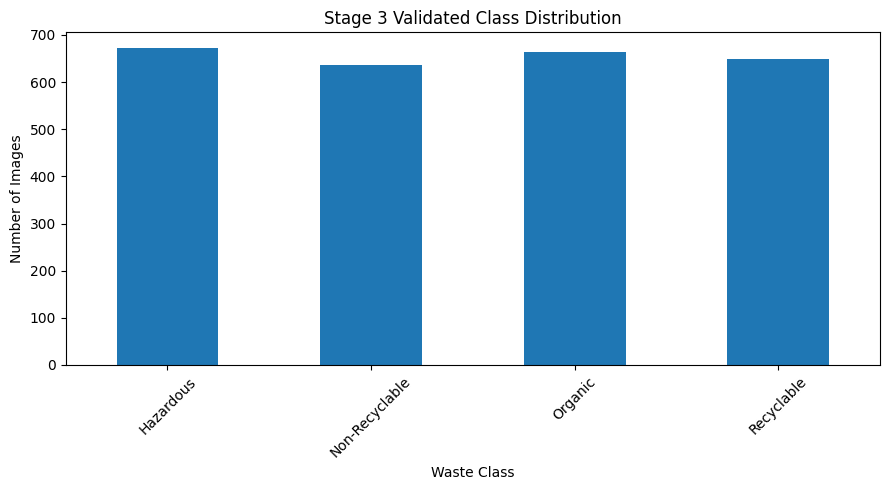

EDA saved to:
/content/drive/MyDrive/Waste_Classification/results/eda_visualizations/group_stage3_class_distribution.png


In [39]:
# ============================================================
# STEP 16 — STAGE 3 CLASS DISTRIBUTION VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt

class_counts = (
    stage3_df["class"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(9, 5))

class_counts.plot(kind="bar")

plt.title("Stage 3 Validated Class Distribution")
plt.xlabel("Waste Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)

plt.tight_layout()

stage3_eda_path = EDA_DIR / "group_stage3_class_distribution.png"

plt.savefig(
    stage3_eda_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("EDA saved to:")
print(stage3_eda_path)

In [40]:
# ============================================================
# STEP 17 — STAGE 4 IMAGE STANDARDIZATION
# RGB + 224 × 224
# ============================================================

from PIL import Image
import shutil
from concurrent.futures import ThreadPoolExecutor, as_completed

# Start fresh
if STAGE4_DIR.exists():
    shutil.rmtree(STAGE4_DIR)

STAGE4_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Collect all Stage 3 images
# ------------------------------------------------------------

stage3_files = [
    p for p in STAGE3_DIR.rglob("*")
    if p.is_file()
]

print("Stage 3 input images:", len(stage3_files))

assert len(stage3_files) == 2622, (
    f"Expected 2622 Stage 3 images, "
    f"found {len(stage3_files)}"
)

# ------------------------------------------------------------
# Standardization function
# ------------------------------------------------------------

def standardize_image(source_path):

    # Preserve the same relative path
    relative_path = source_path.relative_to(STAGE3_DIR)

    destination_path = (
        STAGE4_DIR / relative_path
    ).with_suffix(".jpg")

    destination_path.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    # Open image
    with Image.open(source_path) as img:

        # Convert to RGB
        img = img.convert("RGB")

        # Resize to 224 × 224
        img = img.resize(
            (224, 224),
            Image.Resampling.LANCZOS
        )

        # Save standardized JPEG
        img.save(
            destination_path,
            format="JPEG",
            quality=95
        )

    return destination_path


# ------------------------------------------------------------
# Process images in parallel
# ------------------------------------------------------------

standardized = 0

with ThreadPoolExecutor(max_workers=8) as executor:

    futures = [
        executor.submit(
            standardize_image,
            source_path
        )
        for source_path in stage3_files
    ]

    for future in as_completed(futures):

        future.result()
        standardized += 1

        if standardized % 250 == 0:
            print(
                f"Standardized "
                f"{standardized}/{len(stage3_files)} images..."
            )


print("\n====================================")
print("STAGE 4 STANDARDIZATION COMPLETE")
print("====================================")
print("Images standardized:", standardized)

Stage 3 input images: 2622


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Standardized 250/2622 images...
Standardized 500/2622 images...
Standardized 750/2622 images...
Standardized 1000/2622 images...
Standardized 1250/2622 images...
Standardized 1500/2622 images...


/usr/local/lib/python3.13/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Standardized 1750/2622 images...
Standardized 2000/2622 images...


UnidentifiedImageError: cannot identify image file '/content/drive/MyDrive/Waste_Classification/data/processed/stage3_labels/Hazardous/e-waste/8085 - Copy.jpg'

In [41]:
# ============================================================
# STEP 18A — INVESTIGATE THE STAGE 4 FAILURE
# ============================================================

problem_relative_path = "Hazardous/e-waste/8085 - Copy.jpg"

stage3_problem = STAGE3_DIR / problem_relative_path
stage2_problem = STAGE2_DIR / problem_relative_path

print("Problem file:")
print(stage3_problem)

print("\nStage 3 file exists:", stage3_problem.exists())

if stage3_problem.exists():
    print("Stage 3 file size:", stage3_problem.stat().st_size, "bytes")

print("\nStage 2 direct path exists:", stage2_problem.exists())

if stage2_problem.exists():
    print("Stage 2 direct file size:", stage2_problem.stat().st_size, "bytes")


# ------------------------------------------------------------
# Check Member 1 audit manifest
# ------------------------------------------------------------

member1_problem = stage1_df[
    stage1_df["relative_path"].astype(str).str.replace("\\", "/")
    == problem_relative_path
]

print("\n====================================")
print("MEMBER 1 AUDIT RECORD")
print("====================================")

if len(member1_problem) == 0:
    print("No exact path match found in Member 1 manifest.")
else:
    display(member1_problem)


# ------------------------------------------------------------
# Search Member 1 warnings
# ------------------------------------------------------------

warnings_path = AUDIT_DIR / "member1_image_warnings.csv"

if warnings_path.exists():

    member1_warnings = pd.read_csv(warnings_path)

    warning_matches = member1_warnings[
        member1_warnings.astype(str)
        .apply(
            lambda row: row.str.contains(
                "8085 - Copy.jpg",
                case=False,
                na=False
            ).any(),
            axis=1
        )
    ]

    print("\n====================================")
    print("MEMBER 1 WARNING RECORD")
    print("====================================")

    if len(warning_matches) == 0:
        print("No warning record found for this image.")
    else:
        display(warning_matches)

else:
    print("\nMember 1 warning file was not found.")

Problem file:
/content/drive/MyDrive/Waste_Classification/data/processed/stage3_labels/Hazardous/e-waste/8085 - Copy.jpg

Stage 3 file exists: True
Stage 3 file size: 0 bytes

Stage 2 direct path exists: False

MEMBER 1 AUDIT RECORD
No exact path match found in Member 1 manifest.

MEMBER 1 WARNING RECORD
No warning record found for this image.


In [42]:
# ============================================================
# STEP 18B — LOCATE ORIGINAL 8085 FILE IN STAGE 2
# ============================================================

matches = [
    p for p in STAGE2_DIR.rglob("*")
    if p.is_file() and p.name == "8085 - Copy.jpg"
]

print("Stage 2 matches found:", len(matches))

for p in matches:
    print("\nPath:", p)
    print("Size:", p.stat().st_size, "bytes")

Stage 2 matches found: 1

Path: /content/drive/MyDrive/Waste_Classification/data/processed/stage2_deduplicated/Hazardous/Hazardous/e-waste/8085 - Copy.jpg
Size: 0 bytes


In [43]:
# ============================================================
# STEP 18C — TRACE THE 0-BYTE FILE BACK THROUGH THE PIPELINE
# ============================================================

target_name = "8085 - Copy.jpg"

print("========== STAGE 1 ==========")

stage1_matches = [
    p for p in STAGE1_DIR.rglob("*")
    if p.is_file() and p.name == target_name
]

print("Matches:", len(stage1_matches))

for p in stage1_matches:
    print("Path:", p)
    print("Size:", p.stat().st_size, "bytes")


print("\n========== RAW DATASET ==========")

raw_matches = [
    p for p in RAW_DIR.rglob("*")
    if p.is_file() and p.name == target_name
]

print("Matches:", len(raw_matches))

for p in raw_matches:
    print("Path:", p)
    print("Size:", p.stat().st_size, "bytes")


print("\n========== MEMBER 2 MANIFEST ==========")

member2_matches = stage2_df[
    stage2_df.astype(str)
    .apply(
        lambda row: row.str.contains(
            target_name,
            case=False,
            na=False
        ).any(),
        axis=1
    )
]

print("Manifest matches:", len(member2_matches))

if len(member2_matches) > 0:
    display(member2_matches)

========== STAGE 1 ==========
Matches: 1
Path: /content/drive/MyDrive/Waste_Classification/data/processed/stage1_cleaning/Hazardous/Hazardous/e-waste/8085 - Copy.jpg
Size: 0 bytes

========== RAW DATASET ==========
Matches: 1
Path: /content/drive/MyDrive/Waste_Classification/data/raw/Hazardous/Hazardous/e-waste/8085 - Copy.jpg
Size: 30482 bytes

========== MEMBER 2 MANIFEST ==========
Manifest matches: 1


,file,class,extension
2107,Hazardous/Hazardous/e-waste/8085 - Copy.jpg,Hazardous,.jpg


In [44]:
# ============================================================
# STEP 18D — CHECK FOR ZERO-BYTE FILES
# ============================================================

def find_zero_byte_files(folder):
    return [
        p for p in folder.rglob("*")
        if p.is_file() and p.stat().st_size == 0
    ]


stage1_zero = find_zero_byte_files(STAGE1_DIR)
stage2_zero = find_zero_byte_files(STAGE2_DIR)
stage3_zero = find_zero_byte_files(STAGE3_DIR)

print("========== ZERO-BYTE FILE CHECK ==========")

print("Stage 1 zero-byte files:", len(stage1_zero))
print("Stage 2 zero-byte files:", len(stage2_zero))
print("Stage 3 zero-byte files:", len(stage3_zero))


if stage1_zero:
    print("\nFirst 20 Stage 1 zero-byte files:")
    for p in stage1_zero[:20]:
        print(p.relative_to(STAGE1_DIR))

if stage2_zero:
    print("\nFirst 20 Stage 2 zero-byte files:")
    for p in stage2_zero[:20]:
        print(p.relative_to(STAGE2_DIR))

if stage3_zero:
    print("\nFirst 20 Stage 3 zero-byte files:")
    for p in stage3_zero[:20]:
        print(p.relative_to(STAGE3_DIR))

========== ZERO-BYTE FILE CHECK ==========
Stage 1 zero-byte files: 1
Stage 2 zero-byte files: 1
Stage 3 zero-byte files: 1

First 20 Stage 1 zero-byte files:
Hazardous/Hazardous/e-waste/8085 - Copy.jpg

First 20 Stage 2 zero-byte files:
Hazardous/Hazardous/e-waste/8085 - Copy.jpg

First 20 Stage 3 zero-byte files:
Hazardous/e-waste/8085 - Copy.jpg


In [45]:
# ============================================================
# STEP 18E — REPAIR THE SINGLE CORRUPTED IMAGE
# ============================================================

import shutil

filename = "8085 - Copy.jpg"

# Original valid raw image
raw_file = (
    RAW_DIR
    / "Hazardous"
    / "Hazardous"
    / "e-waste"
    / filename
)

# Stage 1 location
stage1_file = (
    STAGE1_DIR
    / "Hazardous"
    / "Hazardous"
    / "e-waste"
    / filename
)

# Stage 2 location
stage2_file = (
    STAGE2_DIR
    / "Hazardous"
    / "Hazardous"
    / "e-waste"
    / filename
)

# Stage 3 location
stage3_file = (
    STAGE3_DIR
    / "Hazardous"
    / "e-waste"
    / filename
)

print("Raw file exists:", raw_file.exists())
print("Raw file size:", raw_file.stat().st_size, "bytes")

assert raw_file.exists()
assert raw_file.stat().st_size > 0

# ------------------------------------------------------------
# Repair Stage 1
# ------------------------------------------------------------

shutil.copy2(raw_file, stage1_file)

# ------------------------------------------------------------
# Repair Stage 2
# ------------------------------------------------------------

shutil.copy2(raw_file, stage2_file)

# ------------------------------------------------------------
# Repair Stage 3
# ------------------------------------------------------------

shutil.copy2(raw_file, stage3_file)

print("\nRepair complete.")

Raw file exists: True
Raw file size: 30482 bytes

Repair complete.


In [46]:
# ============================================================
# STEP 18F — VERIFY REPAIR
# ============================================================

files_to_check = {
    "Raw": raw_file,
    "Stage 1": stage1_file,
    "Stage 2": stage2_file,
    "Stage 3": stage3_file
}

print("========== REPAIR VERIFICATION ==========")

for stage_name, path in files_to_check.items():

    exists = path.exists()
    size = path.stat().st_size if exists else 0

    print(
        f"{stage_name}: "
        f"exists={exists}, "
        f"size={size} bytes"
    )

    assert exists
    assert size > 0

print("\n✓ The corrupted file has been repaired.")
print("✓ All four copies contain non-zero data.")

========== REPAIR VERIFICATION ==========
Raw: exists=True, size=30482 bytes
Stage 1: exists=True, size=30482 bytes
Stage 2: exists=True, size=30482 bytes
Stage 3: exists=True, size=30482 bytes

✓ The corrupted file has been repaired.
✓ All four copies contain non-zero data.


In [47]:
# ============================================================
# STEP 19 — STAGE 4 IMAGE STANDARDIZATION
# RGB + 224 × 224
# ============================================================

from PIL import Image
import shutil
from concurrent.futures import ThreadPoolExecutor, as_completed

# ------------------------------------------------------------
# Start Stage 4 fresh
# ------------------------------------------------------------

if STAGE4_DIR.exists():
    shutil.rmtree(STAGE4_DIR)

STAGE4_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Collect Stage 3 images
# ------------------------------------------------------------

stage3_files = [
    p for p in STAGE3_DIR.rglob("*")
    if p.is_file()
]

print("Stage 3 input images:", len(stage3_files))

assert len(stage3_files) == 2622, (
    f"Expected 2622 Stage 3 images, "
    f"found {len(stage3_files)}"
)

# ------------------------------------------------------------
# Standardization function
# ------------------------------------------------------------

def standardize_image(source_path):

    relative_path = source_path.relative_to(STAGE3_DIR)

    # All standardized images are saved as JPEG
    destination_path = (
        STAGE4_DIR / relative_path
    ).with_suffix(".jpg")

    destination_path.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    try:

        with Image.open(source_path) as img:

            # Force PIL to fully load the image before closing
            img.load()

            # Convert all image modes safely to RGB.
            # This also handles palette/transparency images.
            if img.mode != "RGB":
                img = img.convert("RGB")

            # Resize to exactly 224 × 224
            img = img.resize(
                (224, 224),
                Image.Resampling.LANCZOS
            )

            # Save as JPEG
            img.save(
                destination_path,
                format="JPEG",
                quality=95
            )

        return {
            "success": True,
            "source": str(source_path),
            "destination": str(destination_path),
            "error": ""
        }

    except Exception as e:

        return {
            "success": False,
            "source": str(source_path),
            "destination": str(destination_path),
            "error": repr(e)
        }


# ------------------------------------------------------------
# Process in parallel
# ------------------------------------------------------------

results = []

with ThreadPoolExecutor(max_workers=8) as executor:

    futures = [
        executor.submit(
            standardize_image,
            source_path
        )
        for source_path in stage3_files
    ]

    completed = 0

    for future in as_completed(futures):

        result = future.result()
        results.append(result)

        completed += 1

        if completed % 250 == 0:
            print(
                f"Processed "
                f"{completed}/{len(stage3_files)} images..."
            )


# ------------------------------------------------------------
# Summarize results
# ------------------------------------------------------------

successful = [
    r for r in results
    if r["success"]
]

failed = [
    r for r in results
    if not r["success"]
]

print("\n====================================")
print("STAGE 4 STANDARDIZATION COMPLETE")
print("====================================")

print("Input images:", len(stage3_files))
print("Successfully standardized:", len(successful))
print("Failed:", len(failed))

if failed:

    print("\nFailed images:")

    for item in failed:
        print("\nSource:", item["source"])
        print("Error:", item["error"])

else:

    print("✓ No standardization failures.")

Stage 3 input images: 2622


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Processed 250/2622 images...
Processed 500/2622 images...
Processed 750/2622 images...
Processed 1000/2622 images...
Processed 1250/2622 images...
Processed 1500/2622 images...


/usr/local/lib/python3.13/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Processed 1750/2622 images...
Processed 2000/2622 images...
Processed 2250/2622 images...
Processed 2500/2622 images...

STAGE 4 STANDARDIZATION COMPLETE
Input images: 2622
Successfully standardized: 2622
Failed: 0
✓ No standardization failures.


In [48]:
# ============================================================
# STEP 20 — VERIFY STAGE 4 FILE COUNT
# ============================================================

stage4_actual_files = [
    p
    for p in STAGE4_DIR.rglob("*")
    if p.is_file()
]

print("Stage 4 output files:", len(stage4_actual_files))

assert len(stage4_actual_files) == 2622, (
    f"Expected 2622 Stage 4 files, "
    f"found {len(stage4_actual_files)}"
)

print("✓ Stage 4 contains exactly 2,622 images.")

Stage 4 output files: 2622
✓ Stage 4 contains exactly 2,622 images.


In [49]:
# ============================================================
# STEP 21 — VERIFY STAGE 4 IMAGE PROPERTIES
# ============================================================

from PIL import Image

bad_dimensions = []
bad_modes = []
unreadable = []

for image_path in stage4_actual_files:

    try:

        with Image.open(image_path) as img:

            # Verify dimensions
            if img.size != (224, 224):
                bad_dimensions.append(
                    (str(image_path), img.size)
                )

            # Verify RGB
            if img.mode != "RGB":
                bad_modes.append(
                    (str(image_path), img.mode)
                )

    except Exception as e:

        unreadable.append(
            (str(image_path), repr(e))
        )


print("====================================")
print("STAGE 4 IMAGE VERIFICATION")
print("====================================")

print("Total images:", len(stage4_actual_files))
print("Wrong dimensions:", len(bad_dimensions))
print("Wrong image mode:", len(bad_modes))
print("Unreadable images:", len(unreadable))


if bad_dimensions:
    print("\nFirst 10 dimension errors:")
    for item in bad_dimensions[:10]:
        print(item)


if bad_modes:
    print("\nFirst 10 mode errors:")
    for item in bad_modes[:10]:
        print(item)


if unreadable:
    print("\nFirst 10 unreadable images:")
    for item in unreadable[:10]:
        print(item)


assert len(bad_dimensions) == 0
assert len(bad_modes) == 0
assert len(unreadable) == 0

print("\n✓ Every Stage 4 image is 224 × 224.")
print("✓ Every Stage 4 image is RGB.")
print("✓ Every Stage 4 image is readable.")
print("✓ Stage 4 verification passed.")

STAGE 4 IMAGE VERIFICATION
Total images: 2622
Wrong dimensions: 0
Wrong image mode: 0
Unreadable images: 0

✓ Every Stage 4 image is 224 × 224.
✓ Every Stage 4 image is RGB.
✓ Every Stage 4 image is readable.
✓ Stage 4 verification passed.


In [51]:
# ============================================================
# STEP 22 — LOAD MEMBER 5 NORMALIZATION SPECIFICATION
# ============================================================

import json

normalization_spec_path = (
    OUTPUT_DIR / "member5_normalization_spec.json"
)

with open(normalization_spec_path, "r") as f:
    normalization_spec = json.load(f)

print("Member 5 normalization specification:")
print(json.dumps(normalization_spec, indent=4))

Member 5 normalization specification:
{
    "resize": [
        224,
        224
    ],
    "to_tensor": true,
    "normalize_mean": [
        0.485,
        0.456,
        0.406
    ],
    "normalize_std": [
        0.229,
        0.224,
        0.225
    ],
    "note": "Normalization is a model-input transform; do not save normalized values as JPEG."
}


In [52]:
# ============================================================
# STEP 23 — DEFINE STAGE 5 NORMALIZATION TRANSFORM
# ============================================================

import torch
from torchvision import transforms

NORMALIZE_MEAN = [
    0.485,
    0.456,
    0.406
]

NORMALIZE_STD = [
    0.229,
    0.224,
    0.225
]

normalize_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=NORMALIZE_MEAN,
        std=NORMALIZE_STD
    )
])

print("Stage 5 normalization transform created.")

print("\nResize:", (224, 224))
print("Mean:", NORMALIZE_MEAN)
print("Std :", NORMALIZE_STD)

print("\n✓ Normalization will be applied at runtime.")
print("✓ No normalized JPEG dataset will be created.")

Stage 5 normalization transform created.

Resize: (224, 224)
Mean: [0.485, 0.456, 0.406]
Std : [0.229, 0.224, 0.225]

✓ Normalization will be applied at runtime.
✓ No normalized JPEG dataset will be created.


In [53]:
# ============================================================
# STEP 24 — VERIFY STAGE 5 NORMALIZATION
# ============================================================

from PIL import Image
import torch

# Select one standardized image
sample_image_path = stage4_actual_files[0]

print("Sample image:")
print(sample_image_path)

# Open original standardized image
with Image.open(sample_image_path) as img:
    sample_image = img.convert("RGB")

print("\nOriginal:")
print("Size:", sample_image.size)
print("Mode:", sample_image.mode)

# Apply normalization transform
normalized_tensor = normalize_transform(sample_image)

print("\nAfter Stage 5 transform:")
print("Tensor shape:", normalized_tensor.shape)
print("Tensor dtype:", normalized_tensor.dtype)
print("Tensor minimum:", normalized_tensor.min().item())
print("Tensor maximum:", normalized_tensor.max().item())
print("Tensor mean:", normalized_tensor.mean().item())

# Verify tensor shape
assert normalized_tensor.shape == (3, 224, 224)

# Verify tensor type
assert isinstance(normalized_tensor, torch.Tensor)

print("\n✓ Image converted to PyTorch tensor.")
print("✓ Tensor has 3 channels.")
print("✓ Tensor dimensions are 3 × 224 × 224.")
print("✓ Stage 5 normalization verification passed.")

Sample image:
/content/drive/MyDrive/Waste_Classification/data/processed/stage4_standardized/Hazardous/batteries/1-s2.0-S2405829720304827-fx1.jpg

Original:
Size: (224, 224)
Mode: RGB

After Stage 5 transform:
Tensor shape: torch.Size([3, 224, 224])
Tensor dtype: torch.float32
Tensor minimum: -2.1179039478302
Tensor maximum: 2.640000104904175
Tensor mean: 1.6873754262924194

✓ Image converted to PyTorch tensor.
✓ Tensor has 3 channels.
✓ Tensor dimensions are 3 × 224 × 224.
✓ Stage 5 normalization verification passed.


In [54]:
# ============================================================
# STEP 25 — LOAD MEMBER 6 AUGMENTATION SPECIFICATION
# ============================================================

import json

augmentation_spec_path = (
    OUTPUT_DIR / "member6_augmentation_spec.json"
)

with open(augmentation_spec_path, "r") as f:
    augmentation_spec = json.load(f)

print("Member 6 augmentation specification:")
print(json.dumps(augmentation_spec, indent=4))

Member 6 augmentation specification:
{
    "resize": [
        224,
        224
    ],
    "horizontal_flip_probability": 0.5,
    "rotation_degrees": 15,
    "brightness": 0.15,
    "contrast": 0.15,
    "saturation": 0.1,
    "normalization_mean": [
        0.485,
        0.456,
        0.406
    ],
    "normalization_std": [
        0.229,
        0.224,
        0.225
    ],
    "validation_test_random_augmentation": false
}


In [55]:
# ============================================================
# STEP 26 — STAGE 6 TRAINING AND EVALUATION TRANSFORMS
# ============================================================

from torchvision import transforms

# ------------------------------------------------------------
# Training transform
# ------------------------------------------------------------
# Random augmentation is applied ONLY to training images.

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        degrees=15
    ),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# ------------------------------------------------------------
# Validation / Test transform
# ------------------------------------------------------------
# NO random augmentation is used here.

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


print("====================================")
print("STAGE 6 TRANSFORMS")
print("====================================")

print("\nTraining transform:")
print(train_transform)

print("\nValidation/Test transform:")
print(eval_transform)

print("\n✓ Training augmentation enabled.")
print("✓ Validation augmentation disabled.")
print("✓ Test augmentation disabled.")
print("✓ ImageNet normalization included.")

STAGE 6 TRANSFORMS

Training transform:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.85, 1.15), contrast=(0.85, 1.15), saturation=(0.9, 1.1), hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Validation/Test transform:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

✓ Training augmentation enabled.
✓ Validation augmentation disabled.
✓ Test augmentation disabled.
✓ ImageNet normalization included.


In [56]:
# ============================================================
# STEP 28 — CREATE FINAL DATASET MANIFEST
# ============================================================

import pandas as pd

final_records = []

for image_path in stage4_actual_files:

    relative_path = image_path.relative_to(
        STAGE4_DIR
    ).as_posix()

    # First folder = main class
    class_name = relative_path.split("/")[0]

    final_records.append({
        "relative_path": relative_path,
        "absolute_path": str(image_path),
        "class": class_name
    })


final_df = pd.DataFrame(final_records)

# Sort for deterministic ordering
final_df = final_df.sort_values(
    "relative_path"
).reset_index(drop=True)

# ------------------------------------------------------------
# Verify class labels
# ------------------------------------------------------------

valid_classes = {
    "Hazardous",
    "Non-Recyclable",
    "Organic",
    "Recyclable"
}

assert set(final_df["class"].unique()) == valid_classes

assert len(final_df) == 2622

# ------------------------------------------------------------
# Save manifest
# ------------------------------------------------------------

final_manifest_path = (
    OUTPUT_DIR / "final_dataset_manifest.csv"
)

final_df.to_csv(
    final_manifest_path,
    index=False
)

print("====================================")
print("FINAL DATASET MANIFEST")
print("====================================")

print("Total images:", len(final_df))

print("\nClass distribution:")
print(
    final_df["class"]
    .value_counts()
    .sort_index()
)

print("\nManifest saved to:")
print(final_manifest_path)

print("\n✓ Final dataset contains 2,622 images.")
print("✓ All four expected classes are present.")
print("✓ Final dataset manifest created.")

FINAL DATASET MANIFEST
Total images: 2622

Class distribution:
class
Hazardous         672
Non-Recyclable    637
Organic           663
Recyclable        650
Name: count, dtype: int64

Manifest saved to:
/content/drive/MyDrive/Waste_Classification/results/outputs/final_dataset_manifest.csv

✓ Final dataset contains 2,622 images.
✓ All four expected classes are present.
✓ Final dataset manifest created.


In [57]:
# ============================================================
# STEP 29 — CREATE FROZEN STRATIFIED 70/15/15 SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# 70% Training / 30% Temporary
# ------------------------------------------------------------

train_df, temp_df = train_test_split(
    final_df,
    test_size=0.30,
    stratify=final_df["class"],
    random_state=42
)

# ------------------------------------------------------------
# Split the remaining 30% into:
# 15% Validation
# 15% Test
# ------------------------------------------------------------

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["class"],
    random_state=42
)

# Reset indexes
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# Add split labels
train_df["split"] = "train"
val_df["split"] = "validation"
test_df["split"] = "test"

# Combine into one frozen split dataframe
frozen_split_df = pd.concat(
    [
        train_df,
        val_df,
        test_df
    ],
    ignore_index=True
)

# ------------------------------------------------------------
# Verify total number of images
# ------------------------------------------------------------

assert len(train_df) + len(val_df) + len(test_df) == 2622

# ------------------------------------------------------------
# Verify there is NO overlap
# ------------------------------------------------------------

train_paths = set(train_df["relative_path"])
val_paths = set(val_df["relative_path"])
test_paths = set(test_df["relative_path"])

assert train_paths.isdisjoint(val_paths)
assert train_paths.isdisjoint(test_paths)
assert val_paths.isdisjoint(test_paths)

# ------------------------------------------------------------
# Save the frozen split
# ------------------------------------------------------------

frozen_split_path = (
    OUTPUT_DIR / "frozen_train_val_test_split.csv"
)

frozen_split_df.to_csv(
    frozen_split_path,
    index=False
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("====================================")
print("FROZEN DATASET SPLIT")
print("====================================")

print(
    f"\nTraining:   {len(train_df)} "
    f"({len(train_df)/2622*100:.2f}%)"
)

print(
    f"Validation: {len(val_df)} "
    f"({len(val_df)/2622*100:.2f}%)"
)

print(
    f"Test:       {len(test_df)} "
    f"({len(test_df)/2622*100:.2f}%)"
)

print("\nClass distribution by split:")

print(
    pd.crosstab(
        frozen_split_df["class"],
        frozen_split_df["split"]
    )
)

print("\nFrozen split saved to:")
print(frozen_split_path)

print("\n✓ Split is stratified.")
print("✓ Train/validation/test sets have no overlap.")
print("✓ Random state = 42.")
print("✓ Frozen split created successfully.")

FROZEN DATASET SPLIT

Training:   1835 (69.98%)
Validation: 393 (14.99%)
Test:       394 (15.03%)

Class distribution by split:
split           test  train  validation
class                                  
Hazardous        101    470         101
Non-Recyclable    95    446          96
Organic          100    464          99
Recyclable        98    455          97

Frozen split saved to:
/content/drive/MyDrive/Waste_Classification/results/outputs/frozen_train_val_test_split.csv

✓ Split is stratified.
✓ Train/validation/test sets have no overlap.
✓ Random state = 42.
✓ Frozen split created successfully.


In [58]:
# ============================================================
# STEP 30 — CREATE MODEL-READY PYTORCH DATASETS
# ============================================================

from torch.utils.data import Dataset
from PIL import Image
import torch

# ------------------------------------------------------------
# Class mapping
# ------------------------------------------------------------

CLASS_TO_IDX = {
    "Hazardous": 0,
    "Non-Recyclable": 1,
    "Organic": 2,
    "Recyclable": 3
}

IDX_TO_CLASS = {
    value: key
    for key, value in CLASS_TO_IDX.items()
}


# ------------------------------------------------------------
# Custom Waste Dataset
# ------------------------------------------------------------

class WasteDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None
    ):

        self.dataframe = dataframe.reset_index(
            drop=True
        )

        self.transform = transform

    def __len__(self):

        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        image_path = row["absolute_path"]

        class_name = row["class"]

        label = CLASS_TO_IDX[class_name]

        # Open standardized image
        image = Image.open(image_path).convert("RGB")

        # Apply appropriate transform
        if self.transform is not None:
            image = self.transform(image)

        return image, label


# ------------------------------------------------------------
# Create datasets
# ------------------------------------------------------------

train_dataset = WasteDataset(
    train_df,
    transform=train_transform
)

val_dataset = WasteDataset(
    val_df,
    transform=eval_transform
)

test_dataset = WasteDataset(
    test_df,
    transform=eval_transform
)


# ------------------------------------------------------------
# Verify dataset sizes
# ------------------------------------------------------------

print("====================================")
print("MODEL-READY DATASETS")
print("====================================")

print("Training dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

assert len(train_dataset) == 1835
assert len(val_dataset) == 393
assert len(test_dataset) == 394

print("\n✓ Dataset sizes match frozen split.")

MODEL-READY DATASETS
Training dataset: 1835
Validation dataset: 393
Test dataset: 394

✓ Dataset sizes match frozen split.


In [59]:
# ============================================================
# STEP 31 — VERIFY MODEL INPUTS
# ============================================================

# Get one sample from each dataset
train_image, train_label = train_dataset[0]
val_image, val_label = val_dataset[0]
test_image, test_label = test_dataset[0]

print("====================================")
print("MODEL INPUT VERIFICATION")
print("====================================")

print("\nTRAIN")
print("Tensor shape:", train_image.shape)
print("Tensor dtype:", train_image.dtype)
print("Label:", train_label)
print("Class:", IDX_TO_CLASS[train_label])

print("\nVALIDATION")
print("Tensor shape:", val_image.shape)
print("Tensor dtype:", val_image.dtype)
print("Label:", val_label)
print("Class:", IDX_TO_CLASS[val_label])

print("\nTEST")
print("Tensor shape:", test_image.shape)
print("Tensor dtype:", test_image.dtype)
print("Label:", test_label)
print("Class:", IDX_TO_CLASS[test_label])


# ------------------------------------------------------------
# Assertions
# ------------------------------------------------------------

assert train_image.shape == (3, 224, 224)
assert val_image.shape == (3, 224, 224)
assert test_image.shape == (3, 224, 224)

assert train_image.dtype == torch.float32
assert val_image.dtype == torch.float32
assert test_image.dtype == torch.float32

assert train_label in IDX_TO_CLASS
assert val_label in IDX_TO_CLASS
assert test_label in IDX_TO_CLASS

print("\n✓ Training input = 3 × 224 × 224 float32 tensor.")
print("✓ Validation input = 3 × 224 × 224 float32 tensor.")
print("✓ Test input = 3 × 224 × 224 float32 tensor.")
print("✓ Labels use the four-class mapping.")
print("✓ Model input verification passed.")

MODEL INPUT VERIFICATION

TRAIN
Tensor shape: torch.Size([3, 224, 224])
Tensor dtype: torch.float32
Label: 2
Class: Organic

VALIDATION
Tensor shape: torch.Size([3, 224, 224])
Tensor dtype: torch.float32
Label: 2
Class: Organic

TEST
Tensor shape: torch.Size([3, 224, 224])
Tensor dtype: torch.float32
Label: 3
Class: Recyclable

✓ Training input = 3 × 224 × 224 float32 tensor.
✓ Validation input = 3 × 224 × 224 float32 tensor.
✓ Test input = 3 × 224 × 224 float32 tensor.
✓ Labels use the four-class mapping.
✓ Model input verification passed.


In [60]:
# ============================================================
# STEP 32 — CREATE PYTORCH DATALOADERS
# ============================================================

from torch.utils.data import DataLoader

# ------------------------------------------------------------
# DataLoader settings
# ------------------------------------------------------------

BATCH_SIZE = 32

# ------------------------------------------------------------
# Training DataLoader
# ------------------------------------------------------------

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

# ------------------------------------------------------------
# Validation DataLoader
# ------------------------------------------------------------

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# ------------------------------------------------------------
# Test DataLoader
# ------------------------------------------------------------

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


# ------------------------------------------------------------
# Display configuration
# ------------------------------------------------------------

print("====================================")
print("PYTORCH DATALOADERS")
print("====================================")

print("Batch size:", BATCH_SIZE)

print("\nTraining batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

print("\n✓ Training loader uses shuffle=True.")
print("✓ Validation loader uses shuffle=False.")
print("✓ Test loader uses shuffle=False.")
print("✓ DataLoaders created successfully.")

PYTORCH DATALOADERS
Batch size: 32

Training batches: 58
Validation batches: 13
Test batches: 13

✓ Training loader uses shuffle=True.
✓ Validation loader uses shuffle=False.
✓ Test loader uses shuffle=False.
✓ DataLoaders created successfully.


In [61]:
# ============================================================
# STEP 33 — VERIFY ONE COMPLETE BATCH
# ============================================================

images, labels = next(iter(train_loader))

print("====================================")
print("BATCH VERIFICATION")
print("====================================")

print("Images shape:", images.shape)
print("Images dtype:", images.dtype)
print("Labels shape:", labels.shape)
print("Labels dtype:", labels.dtype)

print("\nLabels in this batch:")
print(labels.tolist())

print("\nUnique labels in this batch:")
print(sorted(labels.unique().tolist()))


# ------------------------------------------------------------
# Assertions
# ------------------------------------------------------------

assert images.shape[0] <= 32
assert images.shape[1:] == (3, 224, 224)

assert images.dtype == torch.float32
assert labels.dtype == torch.int64

assert all(
    label in [0, 1, 2, 3]
    for label in labels.tolist()
)

print("\n✓ Batch size is correct.")
print("✓ Image shape = [batch, 3, 224, 224].")
print("✓ Images are float32 tensors.")
print("✓ Labels are integer class indices.")
print("✓ All labels belong to the four expected classes.")
print("✓ Complete batch verification passed.")

BATCH VERIFICATION
Images shape: torch.Size([32, 3, 224, 224])
Images dtype: torch.float32
Labels shape: torch.Size([32])
Labels dtype: torch.int64

Labels in this batch:
[3, 2, 2, 1, 0, 3, 0, 3, 1, 2, 3, 0, 0, 1, 1, 0, 2, 2, 0, 2, 2, 2, 3, 3, 0, 2, 3, 2, 1, 1, 0, 3]

Unique labels in this batch:
[0, 1, 2, 3]

✓ Batch size is correct.
✓ Image shape = [batch, 3, 224, 224].
✓ Images are float32 tensors.
✓ Labels are integer class indices.
✓ All labels belong to the four expected classes.
✓ Complete batch verification passed.


In [62]:
# ============================================================
# STEP 34 — CHECK GROUP REPOSITORY STRUCTURE
# ============================================================

from pathlib import Path

PROJECT = Path("/content/drive/MyDrive/Waste_Classification")

print("====================================")
print("GROUP REPOSITORY STRUCTURE")
print("====================================")

# Expected folders
expected_folders = [
    "data",
    "data/raw",
    "data/external",
    "data/processed",
    "notebooks",
    "results",
    "results/eda_visualizations",
    "results/logs",
    "results/outputs",
    "audit_reports"
]

print("\nFOLDERS:")

all_folders_ok = True

for folder in expected_folders:
    path = PROJECT / folder

    if path.exists() and path.is_dir():
        print(f"✓ {folder}")
    else:
        print(f"✗ MISSING: {folder}")
        all_folders_ok = False


# Expected individual notebooks
expected_notebooks = [
    "IT25102140_DatasetCleaning.ipynb",
    "IT25102378_DuplicateDetection.ipynb",
    "IT25102344_LabelValidation.ipynb",
    "IT25102510_ImageStandardization.ipynb",
    "IT25102486_PixelNormalization.ipynb",
    "IT25102515_Augmentation.ipynb",
    "group_pipeline.ipynb"
]

print("\nNOTEBOOKS:")

all_notebooks_ok = True

for notebook in expected_notebooks:
    path = PROJECT / "notebooks" / notebook

    if path.exists():
        print(f"✓ {notebook}")
    else:
        print(f"✗ MISSING: {notebook}")
        all_notebooks_ok = False


# README
print("\nROOT FILES:")

readme = PROJECT / "README.md"

if readme.exists():
    print("✓ README.md")
else:
    print("✗ MISSING: README.md")
    all_folders_ok = False


# Final status
print("\n====================================")

if all_folders_ok and all_notebooks_ok:
    print("✓ Repository structure check passed.")
else:
    print("⚠ Repository structure needs attention.")

print("====================================")

GROUP REPOSITORY STRUCTURE

FOLDERS:
✓ data
✓ data/raw
✓ data/external
✓ data/processed
✓ notebooks
✓ results
✓ results/eda_visualizations
✓ results/logs
✓ results/outputs
✓ audit_reports

NOTEBOOKS:
✓ IT25102140_DatasetCleaning.ipynb
✓ IT25102378_DuplicateDetection.ipynb
✗ MISSING: IT25102344_LabelValidation.ipynb
✓ IT25102510_ImageStandardization.ipynb
✓ IT25102486_PixelNormalization.ipynb
✓ IT25102515_Augmentation.ipynb
✗ MISSING: group_pipeline.ipynb

ROOT FILES:
✓ README.md

⚠ Repository structure needs attention.


In [63]:
# ============================================================
# STEP 35 — FIND MISSING NOTEBOOKS
# ============================================================

from pathlib import Path

PROJECT = Path("/content/drive/MyDrive/Waste_Classification")

print("====================================")
print("SEARCHING FOR NOTEBOOKS")
print("====================================")

for notebook in PROJECT.rglob("*.ipynb"):
    print(notebook.relative_to(PROJECT))

SEARCHING FOR NOTEBOOKS
notebooks/IT25102140_DatasetCleaning.ipynb
notebooks/IT25102378_DuplicateDetection.ipynb
notebooks/T25102344_LabelValidation.ipynb
notebooks/IT25102510_ImageStandardization.ipynb
notebooks/IT25102486_PixelNormalization.ipynb
notebooks/IT25102515_Augmentation.ipynb


In [64]:
# ============================================================
# STEP 35A — FIX LABEL VALIDATION NOTEBOOK NAME
# ============================================================

from pathlib import Path

PROJECT = Path("/content/drive/MyDrive/Waste_Classification")

old_name = PROJECT / "notebooks" / "T25102344_LabelValidation.ipynb"
new_name = PROJECT / "notebooks" / "IT25102344_LabelValidation.ipynb"

if old_name.exists():
    old_name.rename(new_name)
    print("✓ Label validation notebook renamed successfully.")
else:
    print("✗ Old label validation notebook was not found.")

print("\nNew file:")
print(new_name)

✓ Label validation notebook renamed successfully.

New file:
/content/drive/MyDrive/Waste_Classification/notebooks/IT25102344_LabelValidation.ipynb


# Group Pipeline — Waste Image Classification

## Integrated Data Preprocessing Pipeline

This notebook integrates the six preprocessing contributions developed by the
group members into one reproducible preprocessing pipeline for the waste image
classification dataset.

The pipeline combines:

1. Dataset cleaning and image integrity checking
2. Exact and visual duplicate detection
3. Label and class validation
4. Image standardization to RGB and 224 × 224 pixels
5. Pixel normalization using ImageNet mean and standard deviation
6. Training-only image augmentation

After applying the preprocessing stages, the final dataset is frozen and divided
into a common stratified training, validation, and test split.

### Final split

- Training: 1,835 images (69.98%)
- Validation: 393 images (14.99%)
- Test: 394 images (15.03%)
- Total: 2,622 images

The same frozen split will be used by all group members for subsequent model
development and evaluation.

### Reproducibility

The frozen split uses:

- Split ratio: 70% training / 15% validation / 15% testing
- Stratification: Yes
- Random state: 42

The pipeline also verifies that the training, validation, and test sets have no
overlap.

---

## 1. Pipeline Overview

The integrated preprocessing workflow is:

**Raw Dataset → Cleaning → Duplicate Detection → Label Validation → Image
Standardization → Normalization → Training-only Augmentation → Final Dataset →
Frozen Train/Validation/Test Split**

The preprocessing stages are integrated in sequence so that each stage receives
the output of the preceding stage.

The final dataset contains four classes:

- Hazardous
- Non-Recyclable
- Organic
- Recyclable

# 2. Project Setup and Required Paths

This section defines the project directories used throughout the integrated
pipeline.

The pipeline uses the raw dataset, intermediate processed datasets, audit
reports, EDA visualizations, and final output manifests.

# 3. Stage 1 — Dataset Cleaning

**Contributor:** IT25102140

The first preprocessing stage uses the dataset audit and cleaning results
provided by the first group member.

The purpose of this stage is to ensure that the images used by subsequent
preprocessing stages are readable and valid.

The Stage 1 handoff manifest is used as the authoritative record of the
cleaned dataset.

# 4. Stage 2 — Exact and Visual Duplicate Detection

**Contributor:** IT25102378

This stage integrates the duplicate-detection results from the second group
member.

Exact duplicates were identified using file-content hashing, while visually
similar duplicate candidates were identified using perceptual hashing.

The final Stage 2 manifest is used as the authoritative record of the retained
images after duplicate removal.

Dataset size after this stage: **2,622 images**.

# 5. Stage 3 — Label and Class Validation

**Contributor:** IT25102344

This stage integrates the label-validation results from the third group member.

The validated dataset uses four classes:

- Hazardous
- Non-Recyclable
- Organic
- Recyclable

The corresponding numeric encoding is:

- Hazardous → 0
- Non-Recyclable → 1
- Organic → 2
- Recyclable → 3

The validated label manifest is used to reconstruct the Stage 3 dataset.

# 6. Stage 4 — Image Standardization

**Contributor:** IT25102510

All retained images are standardized to a consistent format:

- Colour mode: RGB
- Image size: 224 × 224 pixels

This ensures that every image has a consistent input format for the machine
learning models.

The standardized images are verified for dimensions, RGB mode, and readability.

# 7. Stage 5 — Pixel Normalization

**Contributor:** IT25102486

Pixel normalization is applied as a runtime PyTorch transformation rather than
saving normalized pixel values as new JPEG images.

ImageNet normalization is used:

Mean:

[0.485, 0.456, 0.406]

Standard deviation:

[0.229, 0.224, 0.225]

This transformation is applied when images are loaded for model training and
evaluation.

# 8. Stage 6 — Training-Only Data Augmentation

**Contributor:** IT25102515

Training augmentation is applied dynamically during model training.

The training transformation includes:

- Resize to 224 × 224
- Random horizontal flip with probability 0.5
- Random rotation of up to ±15°
- Color jitter:
  - Brightness = 0.15
  - Contrast = 0.15
  - Saturation = 0.10
- Conversion to tensor
- ImageNet normalization

Validation and test images do not receive random augmentation. They use only
the deterministic evaluation transformation followed by normalization.

# 9. Final Dataset

After integrating all six preprocessing stages, the final dataset contains:

**2,622 images**

Class distribution:

| Class | Images |
|---|---:|
| Hazardous | 672 |
| Non-Recyclable | 637 |
| Organic | 663 |
| Recyclable | 650 |
| **Total** | **2,622** |

The final dataset manifest is saved in:

`results/outputs/final_dataset_manifest.csv`

# 10. Frozen Train / Validation / Test Split

The final dataset is divided once into a common stratified split for all future
model development.

The split is:

- 70% Training
- 15% Validation
- 15% Testing

Random state:

**42**

The split is stratified using the class labels to preserve class proportions.

Once created, this split is frozen and must be used by all group members for
subsequent model development and evaluation.

# 11. Model-Ready PyTorch Dataset and DataLoaders

The frozen split is converted into PyTorch datasets.

Training data uses the training augmentation and normalization transform.

Validation and test data use the deterministic evaluation transform and
normalization.

The DataLoaders use a batch size of 32.

Training uses shuffling, while validation and test data are not shuffled.

# 12. Final Pipeline Verification

The final verification confirms that:

1. The final dataset contains 2,622 images.
2. All four expected classes are present.
3. The frozen split contains 1,835 training images, 393 validation images,
   and 394 test images.
4. The three splits have no overlapping images.
5. Images are converted to 3-channel RGB tensors.
6. Model inputs have dimensions 3 × 224 × 224.
7. Training augmentation is enabled only for the training dataset.
8. Validation and test augmentation are disabled.
9. ImageNet normalization is applied.
10. The PyTorch DataLoaders successfully produce model-ready batches.

In [65]:
# ============================================================
# STEP 39 — FINAL GROUP PIPELINE VERIFICATION
# ============================================================

print("============================================================")
print("              GROUP PIPELINE FINAL VERIFICATION")
print("============================================================")

# ------------------------------------------------------------
# 1. Verify final dataset
# ------------------------------------------------------------

EXPECTED_TOTAL = 2622

assert len(final_df) == EXPECTED_TOTAL

expected_classes = {
    "Hazardous",
    "Non-Recyclable",
    "Organic",
    "Recyclable"
}

actual_classes = set(final_df["class"].unique())

assert actual_classes == expected_classes

print("\n[1] FINAL DATASET")
print(f"✓ Total images: {len(final_df)}")
print("✓ All four expected classes are present.")

print("\nClass distribution:")
print(final_df["class"].value_counts().sort_index())


# ------------------------------------------------------------
# 2. Verify frozen split
# ------------------------------------------------------------

assert len(train_df) == 1835
assert len(val_df) == 393
assert len(test_df) == 394

assert (
    len(train_df)
    + len(val_df)
    + len(test_df)
    == EXPECTED_TOTAL
)

print("\n[2] FROZEN SPLIT")
print(f"✓ Training:   {len(train_df)}")
print(f"✓ Validation: {len(val_df)}")
print(f"✓ Test:       {len(test_df)}")
print("✓ Total matches final dataset.")


# ------------------------------------------------------------
# 3. Verify no overlap
# ------------------------------------------------------------

train_paths = set(train_df["relative_path"])
val_paths = set(val_df["relative_path"])
test_paths = set(test_df["relative_path"])

assert train_paths.isdisjoint(val_paths)
assert train_paths.isdisjoint(test_paths)
assert val_paths.isdisjoint(test_paths)

print("\n[3] SPLIT OVERLAP")
print("✓ Training and validation sets have no overlap.")
print("✓ Training and test sets have no overlap.")
print("✓ Validation and test sets have no overlap.")


# ------------------------------------------------------------
# 4. Verify Stage 4 standardized images
# ------------------------------------------------------------

standardized_image_files = [
    p for p in STAGE4_DIR.rglob("*")
    if p.is_file()
    and p.suffix.lower() in {
        ".jpg", ".jpeg", ".png",
        ".bmp", ".tif", ".tiff"
    }
]

assert len(standardized_image_files) == EXPECTED_TOTAL

print("\n[4] STANDARDIZED DATASET")
print(f"✓ Standardized images: {len(standardized_image_files)}")
print("✓ Expected count = 2,622.")


# ------------------------------------------------------------
# 5. Verify model input
# ------------------------------------------------------------

sample_image, sample_label = train_dataset[0]

assert sample_image.shape == (3, 224, 224)
assert sample_image.dtype == torch.float32
assert sample_label in IDX_TO_CLASS

print("\n[5] MODEL INPUT")
print("✓ Image tensor shape: 3 × 224 × 224")
print("✓ Image dtype: float32")
print("✓ Label belongs to the four-class mapping.")


# ------------------------------------------------------------
# 6. Verify DataLoader
# ------------------------------------------------------------

batch_images, batch_labels = next(iter(train_loader))

assert batch_images.shape[1:] == (3, 224, 224)
assert batch_images.dtype == torch.float32
assert batch_labels.dtype == torch.int64

print("\n[6] DATALOADER")
print(f"✓ Batch image shape: {tuple(batch_images.shape)}")
print(f"✓ Batch label shape: {tuple(batch_labels.shape)}")
print("✓ DataLoader produces valid model inputs.")


# ------------------------------------------------------------
# 7. Final result
# ------------------------------------------------------------

print("\n============================================================")
print("                 GROUP PIPELINE COMPLETE")
print("============================================================")

print("""
✓ Stage 1 — Dataset Cleaning
✓ Stage 2 — Duplicate Detection
✓ Stage 3 — Label Validation
✓ Stage 4 — Image Standardization
✓ Stage 5 — Pixel Normalization
✓ Stage 6 — Training-Only Augmentation

✓ Final dataset: 2,622 images
✓ Frozen split: 70% / 15% / 15%
✓ Random state: 42
✓ No train/validation/test overlap
✓ Model-ready PyTorch datasets created
✓ DataLoaders verified

The integrated group preprocessing pipeline is complete.
============================================================
""")

              GROUP PIPELINE FINAL VERIFICATION

[1] FINAL DATASET
✓ Total images: 2622
✓ All four expected classes are present.

Class distribution:
class
Hazardous         672
Non-Recyclable    637
Organic           663
Recyclable        650
Name: count, dtype: int64

[2] FROZEN SPLIT
✓ Training:   1835
✓ Validation: 393
✓ Test:       394
✓ Total matches final dataset.

[3] SPLIT OVERLAP
✓ Training and validation sets have no overlap.
✓ Training and test sets have no overlap.
✓ Validation and test sets have no overlap.

[4] STANDARDIZED DATASET
✓ Standardized images: 2622
✓ Expected count = 2,622.

[5] MODEL INPUT
✓ Image tensor shape: 3 × 224 × 224
✓ Image dtype: float32
✓ Label belongs to the four-class mapping.

[6] DATALOADER
✓ Batch image shape: (32, 3, 224, 224)
✓ Batch label shape: (32,)
✓ DataLoader produces valid model inputs.

                 GROUP PIPELINE COMPLETE

✓ Stage 1 — Dataset Cleaning
✓ Stage 2 — Duplicate Detection
✓ Stage 3 — Label Validation
✓ Stage 4 — Image

In [66]:
# ============================================================
# STEP 40 — PREPARE GROUP PIPELINE LOCATION
# ============================================================

from pathlib import Path

PROJECT = Path("/content/drive/MyDrive/Waste_Classification")

# Make sure the project directory exists
PROJECT.mkdir(parents=True, exist_ok=True)

print("Group pipeline destination:")
print(PROJECT / "group_pipeline.ipynb")

Group pipeline destination:
/content/drive/MyDrive/Waste_Classification/group_pipeline.ipynb


In [ ]:
# ============================================================
# STEP 40 — SAVE CURRENT COLAB NOTEBOOK TO GOOGLE DRIVE
# ============================================================

import json
from pathlib import Path
from google.colab import _message

PROJECT = Path("/content/drive/MyDrive/Waste_Classification")
OUTPUT_NOTEBOOK = PROJECT / "group_pipeline.ipynb"

# Get the currently open Colab notebook
notebook_data = _message.blocking_request("get_ipynb")

# Extract notebook JSON
notebook = notebook_data["ipynb"]

# Save it directly to Google Drive
with open(OUTPUT_NOTEBOOK, "w", encoding="utf-8") as f:
    json.dump(notebook, f, ensure_ascii=False, indent=2)

print("====================================")
print("GROUP PIPELINE NOTEBOOK SAVED")
print("====================================")

print(f"\nSaved to:")
print(OUTPUT_NOTEBOOK)

print(f"\nNotebook cells: {len(notebook['cells'])}")

assert OUTPUT_NOTEBOOK.exists()
assert OUTPUT_NOTEBOOK.stat().st_size > 0

print(f"File size: {OUTPUT_NOTEBOOK.stat().st_size:,} bytes")

print("\n✓ Current Colab notebook captured.")
print("✓ Notebook saved directly to Google Drive.")
print("✓ group_pipeline.ipynb created successfully.")